In [102]:
import numpy as np 
import glob
import os
import math
import mne
import re

In [103]:
STAGE_CLASSIFICATION = {
    np.int64(0):'W',
    np.int64(1):'N1',
    np.int64(2):'N2',
    np.int64(3):'N3',
    np.int64(4):'REM',
}

STAGE_CODES = {
    np.str_('Sleep stage W'): 'W',
    np.str_('Sleep stage 1'): 'N1',
    np.str_('Sleep stage 2'): 'N2',
    np.str_('Sleep stage 3'): 'N3',
    np.str_('Sleep stage 4'): 'N3',
    np.str_('Sleep stage R'): 'REM',
    np.str_('Sleep stage ?'): 'I',
    np.str_('Movement time'): 'I'
}

STAGE_TO_INT = {
    'W': 0,
    'N1': 1,
    'N2': 2,
    'N3': 3,
    'REM': 4,
    'I': 5,
}

In [104]:
def getData(all_subjects):
    all_list = []
    for folder in all_subjects:
        f= glob.glob(os.path.join(folder,"*.npz"))
        subs = [ i for i in f]
        all_list.extend(subs)
    return all_list

In [105]:
all_path_npz = 'iSLEEPS/saswata/sleep_project_data/nimhans_preprocessed_data/numpy_subjects'
data_dir = glob.glob(os.path.join(all_path_npz,"*.npz"))
all_subjects = [ i for i in data_dir]
all_subjects.sort()

In [106]:
base_folder = f'iSLEEPS/saswata/sleep_project_data/nimhans_preprocessed_data/numpy_samples'
data_dir = glob.glob(os.path.join(base_folder,"*"))
all_subjects_folders = [ i for i in data_dir]
all_subjects_folders.sort()
windowed_list = getData(all_subjects_folders)

In [107]:
patient_sleep_stages_isleeps = {}
for file_path in windowed_list:
    filename = os.path.basename(file_path)
    patient_id = 'SN_'+filename.split('_')[0]
    epoch_num = int(filename.split('_')[1].split('.')[0])
    file = np.load(file_path)
    stage = np.squeeze(file['y'][math.ceil(file['y'].shape[0]/2)], axis=-1)
    if patient_id not in patient_sleep_stages_isleeps:
        patient_sleep_stages_isleeps[patient_id] = {}
    patient_sleep_stages_isleeps[patient_id][epoch_num] = STAGE_CLASSIFICATION[stage]
for patient_id in patient_sleep_stages_isleeps:
    patient_sleep_stages_isleeps[patient_id] = dict(sorted(patient_sleep_stages_isleeps[patient_id].items()))

In [108]:
data_path = 'iSLEEPS/saswata/sleep-cassette'
edf_files = [f for f in os.listdir(data_path) if f.endswith('.edf')]

# Create nested dictionary for all hypnogram files
all_hypnograms = {}

# Get all hypnogram files
hypnogram_files = [f for f in edf_files if 'Hypnogram' in f]

for hypno_file in hypnogram_files:
    # Extract patient ID using regex
    patient_id = re.search(r'(SC\d+)', hypno_file).group(1)
    
    # Read hypnogram annotations
    hypno_path = os.path.join(data_path, hypno_file)
    hypno_annotations = mne.read_annotations(hypno_path)
    
    # Create epoch-wise sleep stage dictionary for this patient
    patient_epochs = {}
    for epoch_num, (onset, duration, description) in enumerate(zip(hypno_annotations.onset, 
                                                                   hypno_annotations.duration, 
                                                                   hypno_annotations.description)):
        if STAGE_CODES[description] == 'I':
            # Find the most recent non-'I' stage
            if epoch_num > 0:
            # Look backwards for the last non-'I' stage
                for prev_epoch in range(epoch_num - 1, -1, -1):
                    if prev_epoch + 1 in patient_epochs and patient_epochs[prev_epoch + 1] != 'I':
                        patient_epochs[epoch_num + 1] = patient_epochs[prev_epoch + 1]
                    break
            else:
                # If no previous non-'I' stage found, default to 'W'
                patient_epochs[epoch_num + 1] = 'W'
        else:
            patient_epochs[epoch_num + 1] = STAGE_CODES[description]
    
    # Add to main dictionary
    all_hypnograms[patient_id] = patient_epochs
patient_sleep_stages_sc = all_hypnograms

In [109]:
isleeps_value_lists = [list(patient_epochs.values()) for patient_epochs in patient_sleep_stages_isleeps.values()]
sc_value_lists = [list(patient_epochs.values()) for patient_epochs in patient_sleep_stages_sc.values()]

In [110]:
import pandas as pd
from scipy.stats import chi2_contingency
from collections import Counter
from scipy.stats import ttest_ind
import numpy as np

# Flatten the lists and count symbol frequencies
isleeps_flat = [stage for sublist in isleeps_value_lists for stage in sublist]
sc_flat = [stage for sublist in sc_value_lists for stage in sublist]

# Count frequencies for each dataset
isleeps_counts = Counter(isleeps_flat)
sc_counts = Counter(sc_flat)

# Get all unique stages
all_stages = set(isleeps_counts.keys()) | set(sc_counts.keys())

# Create contingency table
contingency_data = []
for stage in sorted(all_stages):
    isleeps_count = isleeps_counts.get(stage, 0)
    sc_count = sc_counts.get(stage, 0)
    contingency_data.append([isleeps_count, sc_count])

# Convert to DataFrame for better visualization
contingency_df = pd.DataFrame(contingency_data, 
                            columns=['iSLEEPS', 'Sleep-Cassette'],
                            index=sorted(all_stages))

print("Contingency Table:")
print(contingency_df)
print(f"\nTotal samples - iSLEEPS: {sum(isleeps_counts.values())}, Sleep-Cassette: {sum(sc_counts.values())}")

# Perform chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_data)

print(f"\nChi-square test results:")
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value:.6e}")
print(f"Degrees of freedom: {dof}")
print(f"Critical value (α=0.05): {chi2_stat > 11.07:.0f}")

if p_value < 0.05:
    print("Result: Reject the null hypothesis - distributions are significantly different.")
else:
    print("Result: Fail to reject the null hypothesis - no significant difference in distributions.")

# Perform t-tests for statistical significance of proportion differences
print(f"\nT-test analysis for proportion differences:")
print("-" * 50)
# For each stage, create binary arrays (1 if stage present, 0 if not) for each sequence
for stage in sorted(all_stages):
    # Create binary arrays for each sequence in both datasets
    isleeps_stage_props = []
    sc_stage_props = []
    
    # Calculate proportion of each stage per sequence in iSLEEPS
    for seq in isleeps_value_lists:
        stage_count = seq.count(stage)
        proportion = stage_count / len(seq) if len(seq) > 0 else 0
        isleeps_stage_props.append(proportion)
    
    # Calculate proportion of each stage per sequence in Sleep-Cassette
    for seq in sc_value_lists:
        stage_count = seq.count(stage)
        proportion = stage_count / len(seq) if len(seq) > 0 else 0
        sc_stage_props.append(proportion)
    
    # Perform independent t-test
    t_stat, t_p_value = ttest_ind(isleeps_stage_props, sc_stage_props)
    
    # Calculate means and standard deviations
    isleeps_mean = np.mean(isleeps_stage_props)
    sc_mean = np.mean(sc_stage_props)
    isleeps_std = np.std(isleeps_stage_props, ddof=1)
    sc_std = np.std(sc_stage_props, ddof=1)
    
    print(f"{stage}:")
    print(f"  iSLEEPS: {isleeps_mean:.4f} ± {isleeps_std:.4f} (n={len(isleeps_stage_props)})")
    print(f"  Sleep-Cassette: {sc_mean:.4f} ± {sc_std:.4f} (n={len(sc_stage_props)})")
    print(f"  t-statistic: {t_stat:.4f}, p-value: {t_p_value:.6f}")
    
    if t_p_value < 0.05:
        significance = "Significant"
        if isleeps_mean > sc_mean:
            direction = "higher in iSLEEPS"
        else:
            direction = "higher in Sleep-Cassette"
    else:
        significance = "Not significant"
        direction = "no significant difference"
    
    print(f"  Result: {significance} - {direction}")
    print()

# Calculate proportions for comparison
print("\nProportions comparison:")
isleeps_total = sum(isleeps_counts.values())
sc_total = sum(sc_counts.values())

for stage in sorted(all_stages):
    isleeps_prop = isleeps_counts.get(stage, 0) / isleeps_total
    sc_prop = sc_counts.get(stage, 0) / sc_total
    print(f"{stage}: iSLEEPS={isleeps_prop:.3f}, Sleep-Cassette={sc_prop:.3f}")

Contingency Table:
     iSLEEPS  Sleep-Cassette
N1      2379            5957
N2      9818            6430
N3      2093            4572
REM     2810            1613
W       6092            3858

Total samples - iSLEEPS: 23192, Sleep-Cassette: 22430

Chi-square test results:
Chi-square statistic: 3978.1753
p-value: 0.000000e+00
Degrees of freedom: 4
Critical value (α=0.05): 1
Result: Reject the null hypothesis - distributions are significantly different.

T-test analysis for proportion differences:
--------------------------------------------------
N1:
  iSLEEPS: 0.1024 ± 0.0709 (n=100)
  Sleep-Cassette: 0.2665 ± 0.1019 (n=153)
  t-statistic: -14.0279, p-value: 0.000000
  Result: Significant - higher in Sleep-Cassette

N2:
  iSLEEPS: 0.4239 ± 0.1210 (n=100)
  Sleep-Cassette: 0.2897 ± 0.0623 (n=153)
  t-statistic: 11.5847, p-value: 0.000000
  Result: Significant - higher in iSLEEPS

N3:
  iSLEEPS: 0.0907 ± 0.0718 (n=100)
  Sleep-Cassette: 0.1954 ± 0.1462 (n=153)
  t-statistic: -6.6528, p-

In [111]:
import numpy as np
from scipy.special import kl_div
from scipy.stats import ttest_ind

# Calculate symbol frequencies for each dataset
isleeps_flat = [stage for sublist in isleeps_value_lists for stage in sublist]
sc_flat = [stage for sublist in sc_value_lists for stage in sublist]

# Get all unique stages and sort them for consistent ordering
all_stages = sorted(set(isleeps_flat + sc_flat))

# Calculate probability distributions
isleeps_counts = {stage: isleeps_flat.count(stage) for stage in all_stages}
sc_counts = {stage: sc_flat.count(stage) for stage in all_stages}

isleeps_total = len(isleeps_flat)
sc_total = len(sc_flat)

# Convert to probability arrays
P = np.array([isleeps_counts[stage] / isleeps_total for stage in all_stages])
Q = np.array([sc_counts[stage] / sc_total for stage in all_stages])

# Add small epsilon to avoid log(0) issues
epsilon = 1e-10
P = P + epsilon
Q = Q + epsilon

# Normalize after adding epsilon
P = P / P.sum()
Q = Q / Q.sum()

# Calculate KL divergences
kl_pq = np.sum(kl_div(P, Q))  # D_KL(P||Q) using scipy
kl_qp = np.sum(kl_div(Q, P))  # D_KL(Q||P) using scipy

print("KL Divergence Analysis:")
print(f"Stage order: {all_stages}")
print(f"iSLEEPS distribution (P): {P}")
print(f"Sleep-Cassette distribution (Q): {Q}")
print(f"\nKL divergence D_KL(iSLEEPS||Sleep-Cassette): {kl_pq:.6f}")
print(f"KL divergence D_KL(Sleep-Cassette||iSLEEPS): {kl_qp:.6f}")
print(f"Average KL divergence: {(kl_pq + kl_qp) / 2:.6f}")

# Interpretation
if kl_pq < 0.1 and kl_qp < 0.1:
    print("\nInterpretation: Very similar distributions (KL < 0.1)")
elif kl_pq < 0.5 and kl_qp < 0.5:
    print("\nInterpretation: Moderately different distributions (KL < 0.5)")
else:
    print("\nInterpretation: Significantly different distributions (KL ≥ 0.5)")

    # Perform t-tests for statistical significance of proportion differences
    print(f"\nT-test analysis for proportion differences:")
    print("-" * 50)

# For each stage, create arrays of proportions per sequence for each dataset
for stage in all_stages:
    # Calculate proportion of each stage per sequence in iSLEEPS
    isleeps_stage_props = []
    for seq in isleeps_value_lists:
        stage_count = seq.count(stage)
        proportion = stage_count / len(seq) if len(seq) > 0 else 0
        isleeps_stage_props.append(proportion)
    
    # Calculate proportion of each stage per sequence in Sleep-Cassette
    sc_stage_props = []
    for seq in sc_value_lists:
        stage_count = seq.count(stage)
        proportion = stage_count / len(seq) if len(seq) > 0 else 0
        sc_stage_props.append(proportion)
    
    # Perform independent t-test
    t_stat, t_p_value = ttest_ind(isleeps_stage_props, sc_stage_props)
    
    # Calculate means and standard deviations
    isleeps_mean = np.mean(isleeps_stage_props)
    sc_mean = np.mean(sc_stage_props)
    isleeps_std = np.std(isleeps_stage_props, ddof=1)
    sc_std = np.std(sc_stage_props, ddof=1)
    
    print(f"{stage}:")
    print(f"  iSLEEPS: {isleeps_mean:.4f} ± {isleeps_std:.4f} (n={len(isleeps_stage_props)})")
    print(f"  Sleep-Cassette: {sc_mean:.4f} ± {sc_std:.4f} (n={len(sc_stage_props)})")
    print(f"  t-statistic: {t_stat:.4f}, p-value: {t_p_value:.6f}")
    
    if t_p_value < 0.05:
        significance = "Significant"
        if isleeps_mean > sc_mean:
            direction = "higher in iSLEEPS"
        else:
            direction = "higher in Sleep-Cassette"
    else:
        significance = "Not significant"
        direction = "no significant difference"
    
    print(f"  Result: {significance} - {direction}")
    print()

KL Divergence Analysis:
Stage order: ['N1', 'N2', 'N3', 'REM', 'W']
iSLEEPS distribution (P): [0.10257848 0.42333563 0.09024664 0.12116247 0.26267679]
Sleep-Cassette distribution (Q): [0.26558181 0.28666964 0.20383415 0.07191262 0.17200178]

KL divergence D_KL(iSLEEPS||Sleep-Cassette): 0.168350
KL divergence D_KL(Sleep-Cassette||iSLEEPS): 0.196624
Average KL divergence: 0.182487

Interpretation: Moderately different distributions (KL < 0.5)
N1:
  iSLEEPS: 0.1024 ± 0.0709 (n=100)
  Sleep-Cassette: 0.2665 ± 0.1019 (n=153)
  t-statistic: -14.0279, p-value: 0.000000
  Result: Significant - higher in Sleep-Cassette

N2:
  iSLEEPS: 0.4239 ± 0.1210 (n=100)
  Sleep-Cassette: 0.2897 ± 0.0623 (n=153)
  t-statistic: 11.5847, p-value: 0.000000
  Result: Significant - higher in iSLEEPS

N3:
  iSLEEPS: 0.0907 ± 0.0718 (n=100)
  Sleep-Cassette: 0.1954 ± 0.1462 (n=153)
  t-statistic: -6.6528, p-value: 0.000000
  Result: Significant - higher in Sleep-Cassette

REM:
  iSLEEPS: 0.1194 ± 0.0793 (n=100)
  

In [112]:
import numpy as np
from collections import Counter
from scipy.stats import ttest_ind

def calculate_shannon_entropy(sequence_list):
    """Calculate Shannon entropy for a list of sequences"""
    # Flatten all sequences into one list
    flat_sequence = [stage for sublist in sequence_list for stage in sublist]
    
    # Count frequencies
    counts = Counter(flat_sequence)
    total = len(flat_sequence)
    
    # Calculate probabilities
    probabilities = [count / total for count in counts.values()]
    
    # Calculate Shannon entropy
    entropy = -sum(p * np.log2(p) for p in probabilities if p > 0)
    
    return entropy, counts, total

# Calculate Shannon entropy for both datasets
isleeps_entropy, isleeps_counts, isleeps_total = calculate_shannon_entropy(isleeps_value_lists)
sc_entropy, sc_counts, sc_total = calculate_shannon_entropy(sc_value_lists)

print("Shannon Entropy Analysis:")
print(f"iSLEEPS Shannon entropy: {isleeps_entropy:.6f} bits")
print(f"Sleep-Cassette Shannon entropy: {sc_entropy:.6f} bits")
print(f"Entropy difference: {abs(isleeps_entropy - sc_entropy):.6f} bits")

# Calculate maximum possible entropy (uniform distribution)
n_stages = len(set(stage for sublist in isleeps_value_lists + sc_value_lists for stage in sublist))
max_entropy = np.log2(n_stages)

print(f"\nMaximum possible entropy (uniform distribution): {max_entropy:.6f} bits")
print(f"iSLEEPS entropy ratio: {isleeps_entropy / max_entropy:.3f}")
print(f"Sleep-Cassette entropy ratio: {sc_entropy / max_entropy:.3f}")

# Interpretation
print(f"\nInterpretation:")
if abs(isleeps_entropy - sc_entropy) < 0.1:
    print("Very similar entropy values - both datasets have similar symbol distribution patterns")
elif abs(isleeps_entropy - sc_entropy) < 0.3:
    print("Moderately different entropy values - some difference in symbol distribution patterns")
else:
    print("Significantly different entropy values - notable difference in symbol distribution patterns")

if isleeps_entropy > sc_entropy:
    print("iSLEEPS has higher entropy - more uniform/diverse symbol distribution")
else:
    print("Sleep-Cassette has higher entropy - more diverse symbol distribution")

# Calculate entropy for each individual sequence
def calculate_sequence_entropies(sequence_list):
    """Calculate Shannon entropy for each individual sequence"""
    entropies = []
    for sequence in sequence_list:
        counts = Counter(sequence)
        total = len(sequence)
        if total > 0:
            probabilities = [count / total for count in counts.values()]
            entropy = -sum(p * np.log2(p) for p in probabilities if p > 0)
            entropies.append(entropy)
        else:
            entropies.append(0)
    return entropies
# Calculate individual sequence entropies
isleeps_seq_entropies = calculate_sequence_entropies(isleeps_value_lists)
sc_seq_entropies = calculate_sequence_entropies(sc_value_lists)
# Perform t-test on individual sequence entropies
t_stat, p_value = ttest_ind(isleeps_seq_entropies, sc_seq_entropies)
print(f"\nT-test for entropy differences:")
print(f"iSLEEPS mean entropy per sequence: {np.mean(isleeps_seq_entropies):.6f} ± {np.std(isleeps_seq_entropies, ddof=1):.6f}")
print(f"Sleep-Cassette mean entropy per sequence: {np.mean(sc_seq_entropies):.6f} ± {np.std(sc_seq_entropies, ddof=1):.6f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6e}")
if p_value < 0.05:
    significance = "Significant"
    if np.mean(isleeps_seq_entropies) > np.mean(sc_seq_entropies):
        direction = "iSLEEPS has significantly higher entropy per sequence"
    else:
        direction = "Sleep-Cassette has significantly higher entropy per sequence"
else:
    significance = "Not significant"
    direction = "no significant difference in entropy between datasets"
print(f"Result: {significance} - {direction}")

Shannon Entropy Analysis:
iSLEEPS Shannon entropy: 2.050681 bits
Sleep-Cassette Shannon entropy: 2.202330 bits
Entropy difference: 0.151649 bits

Maximum possible entropy (uniform distribution): 2.321928 bits
iSLEEPS entropy ratio: 0.883
Sleep-Cassette entropy ratio: 0.948

Interpretation:
Moderately different entropy values - some difference in symbol distribution patterns
Sleep-Cassette has higher entropy - more diverse symbol distribution

T-test for entropy differences:
iSLEEPS mean entropy per sequence: 1.840038 ± 0.195917
Sleep-Cassette mean entropy per sequence: 2.028382 ± 0.144029
t-statistic: -8.8001
p-value: 2.257813e-16
Result: Significant - Sleep-Cassette has significantly higher entropy per sequence


In [113]:
from collections import defaultdict, Counter
import numpy as np
from scipy.stats import chi2_contingency
from scipy.special import kl_div

def extract_bigrams(sequence_list, exclude_self_transitions=False):
    """Extract all bigrams from a list of sequences"""
    bigrams = []
    for sequence in sequence_list:
        for i in range(len(sequence) - 1):
            current_stage = sequence[i]
            next_stage = sequence[i + 1]
            # Skip self-transitions if requested
            if exclude_self_transitions and current_stage == next_stage:
                continue
            bigrams.append((current_stage, next_stage))
    return bigrams

def build_transition_matrix(sequence_list, stages, exclude_self_transitions=False, subset_percentage=0.8, num_iterations=100):
    """Build transition matrix and counts for sequences using bootstrap sampling"""
    n_stages = len(stages)
    stage_to_idx = {stage: i for i, stage in enumerate(stages)}
    
    # Store all probability matrices from bootstrap samples
    prob_matrices = []
    
    for iteration in range(num_iterations):
        # Randomly sample subset_percentage of sequences
        sample_size = int(len(sequence_list) * subset_percentage)
        sampled_sequences = np.random.choice(len(sequence_list), size=sample_size, replace=False)
        subset_sequences = [sequence_list[i] for i in sampled_sequences]
        
        # Build transition counts for this subset
        transition_counts = defaultdict(lambda: defaultdict(int))
        
        for sequence in subset_sequences:
            for i in range(len(sequence) - 1):
                current_stage = sequence[i]
                next_stage = sequence[i + 1]
                # Skip self-transitions if requested
                if exclude_self_transitions and current_stage == next_stage:
                    continue
                transition_counts[current_stage][next_stage] += 1
        
        # Convert to probability matrix for this subset
        prob_matrix = np.zeros((n_stages, n_stages))
        
        for i, from_stage in enumerate(stages):
            row_sum = sum(transition_counts[from_stage].values())
            for j, to_stage in enumerate(stages):
                count = transition_counts[from_stage][to_stage]
                prob_matrix[i, j] = count / row_sum if row_sum > 0 else 0
        
        prob_matrices.append(prob_matrix)
    
    # Average all probability matrices
    avg_prob_matrix = np.mean(prob_matrices, axis=0)
    
    # Build final count matrix using full dataset for consistency
    transition_counts = defaultdict(lambda: defaultdict(int))
    total_transitions = 0
    
    for sequence in sequence_list:
        for i in range(len(sequence) - 1):
            current_stage = sequence[i]
            next_stage = sequence[i + 1]
            # Skip self-transitions if requested
            if exclude_self_transitions and current_stage == next_stage:
                continue
            transition_counts[current_stage][next_stage] += 1
            total_transitions += 1
    
    # Convert to final count matrix
    count_matrix = np.zeros((n_stages, n_stages))
    
    for i, from_stage in enumerate(stages):
        for j, to_stage in enumerate(stages):
            count = transition_counts[from_stage][to_stage]
            count_matrix[i, j] = count
    
    return count_matrix, avg_prob_matrix, transition_counts

# Get all unique stages
all_stages = sorted(set(stage for sublist in isleeps_value_lists + sc_value_lists 
                       for stage in sublist))
print(f"Sleep stages: {all_stages}")

# Extract bigrams from both datasets (including self-transitions)
isleeps_bigrams_with_self = extract_bigrams(isleeps_value_lists, exclude_self_transitions=False)
sc_bigrams_with_self = extract_bigrams(sc_value_lists, exclude_self_transitions=False)

print(f"\nBigram counts (including self-transitions):")
print(f"iSLEEPS bigrams: {len(isleeps_bigrams_with_self)}")
print(f"Sleep-Cassette bigrams: {len(sc_bigrams_with_self)}")

# Build transition matrices (including self-transitions)
isleeps_counts_with_self, isleeps_probs_with_self, isleeps_trans_with_self = build_transition_matrix(isleeps_value_lists, all_stages, exclude_self_transitions=False)
sc_counts_with_self, sc_probs_with_self, sc_trans_with_self = build_transition_matrix(sc_value_lists, all_stages, exclude_self_transitions=False)

print(f"\niSLEEPS Transition Matrix (probabilities, with self-transitions):")
transition_df_isleeps_with_self = pd.DataFrame(isleeps_probs_with_self, 
                                   columns=all_stages, 
                                   index=all_stages)
print(transition_df_isleeps_with_self.round(3))

print(f"\nSleep-Cassette Transition Matrix (probabilities, with self-transitions):")
transition_df_sc_with_self = pd.DataFrame(sc_probs_with_self, 
                               columns=all_stages, 
                               index=all_stages)
print(transition_df_sc_with_self.round(3))

# Extract bigrams from both datasets (excluding self-transitions)
isleeps_bigrams = extract_bigrams(isleeps_value_lists, exclude_self_transitions=True)
sc_bigrams = extract_bigrams(sc_value_lists, exclude_self_transitions=True)

print(f"\nBigram counts (excluding self-transitions):")
print(f"iSLEEPS bigrams: {len(isleeps_bigrams)}")
print(f"Sleep-Cassette bigrams: {len(sc_bigrams)}")

# Build transition matrices (excluding self-transitions)
isleeps_counts, isleeps_probs, isleeps_trans = build_transition_matrix(isleeps_value_lists, all_stages, exclude_self_transitions=True)
sc_counts, sc_probs, sc_trans = build_transition_matrix(sc_value_lists, all_stages, exclude_self_transitions=True)

print(f"\niSLEEPS Transition Matrix (probabilities, no self-transitions):")
transition_df_isleeps = pd.DataFrame(isleeps_probs, 
                                   columns=all_stages, 
                                   index=all_stages)
print(transition_df_isleeps.round(3))

print(f"\nSleep-Cassette Transition Matrix (probabilities, no self-transitions):")
transition_df_sc = pd.DataFrame(sc_probs, 
                               columns=all_stages, 
                               index=all_stages)
print(transition_df_sc.round(3))

# Chi-square test on transition counts
print(f"\nChi-square test on transition matrices (excluding self-transitions):")
# Create masks to exclude diagonal elements (self-transitions)
n_stages = len(all_stages)
mask = ~np.eye(n_stages, dtype=bool)  # Exclude diagonal elements

# Flatten the count matrices and exclude self-transitions
isleeps_flat = isleeps_counts[mask]
sc_flat = sc_counts[mask]

# Create contingency table for chi-square test
contingency_transitions = np.array([isleeps_flat, sc_flat])
chi2_trans, p_trans, dof_trans, expected_trans = chi2_contingency(contingency_transitions)

print(f"Chi-square statistic: {chi2_trans:.4f}")
print(f"p-value: {p_trans}")
print(f"Degrees of freedom: {dof_trans}")

if p_trans < 0.05:
    print("Result: Transition patterns are significantly different")
else:
    print("Result: No significant difference in transition patterns")

# KL divergence on transition probabilities
print(f"\nKL Divergence on transition matrices (excluding self-transitions):")
epsilon = 1e-10
isleeps_probs_flat = isleeps_probs.flatten() + epsilon
sc_probs_flat = sc_probs.flatten() + epsilon

# Normalize after adding epsilon
isleeps_probs_flat = isleeps_probs_flat / isleeps_probs_flat.sum()
sc_probs_flat = sc_probs_flat / sc_probs_flat.sum()

kl_isleeps_sc = np.sum(isleeps_probs_flat * np.log(isleeps_probs_flat / sc_probs_flat))
kl_sc_isleeps = np.sum(sc_probs_flat * np.log(sc_probs_flat / isleeps_probs_flat))

print(f"KL(iSLEEPS||Sleep-Cassette): {kl_isleeps_sc:.6f}")
print(f"KL(Sleep-Cassette||iSLEEPS): {kl_sc_isleeps:.6f}")
print(f"Average KL divergence: {(kl_isleeps_sc + kl_sc_isleeps) / 2:.6f}")

if kl_isleeps_sc < 0.1 and kl_sc_isleeps < 0.1:
    print("Interpretation: Very similar transition patterns (KL < 0.1)")
elif kl_isleeps_sc < 0.5 and kl_sc_isleeps < 0.5:
    print("Interpretation: Moderately different transition patterns (KL < 0.5)")
else:
    print("Interpretation: Significantly different transition patterns (KL ≥ 0.5)")


# T-test analysis for transition probabilities
print(f"\nT-test analysis for transition probability differences:")
print("-" * 60)

# Store insignificant transitions
insignificant_transitions = []

# For each transition (from_stage -> to_stage), calculate probabilities per sequence
for i, from_stage in enumerate(all_stages):
    for j, to_stage in enumerate(all_stages):
        # Skip self-transitions since we excluded them
        if from_stage == to_stage:
            continue
            
        # Calculate transition probabilities per sequence for iSLEEPS
        isleeps_trans_probs = []
        for seq in isleeps_value_lists:
            from_count = 0
            transition_count = 0
            for k in range(len(seq) - 1):
                if seq[k] == from_stage and seq[k] != seq[k + 1]:  # Exclude self-transitions
                    from_count += 1
                    if seq[k + 1] == to_stage:
                        transition_count += 1
            
            # Calculate proportion of transitions from from_stage to to_stage
            proportion = transition_count / from_count if from_count > 0 else 0
            isleeps_trans_probs.append(proportion)
        
        # Calculate transition probabilities per sequence for Sleep-Cassette
        sc_trans_probs = []
        for seq in sc_value_lists:
            from_count = 0
            transition_count = 0
            for k in range(len(seq) - 1):
                if seq[k] == from_stage and seq[k] != seq[k + 1]:  # Exclude self-transitions
                    from_count += 1
                    if seq[k + 1] == to_stage:
                        transition_count += 1
            
            # Calculate proportion of transitions from from_stage to to_stage
            proportion = transition_count / from_count if from_count > 0 else 0
            sc_trans_probs.append(proportion)
        
        # Only perform t-test if both groups have non-zero variance
        if np.std(isleeps_trans_probs) > 0 or np.std(sc_trans_probs) > 0:
            t_stat, t_p_value = ttest_ind(isleeps_trans_probs, sc_trans_probs)
            
            # Calculate means and standard deviations
            isleeps_mean = np.mean(isleeps_trans_probs)
            sc_mean = np.mean(sc_trans_probs)
            isleeps_std = np.std(isleeps_trans_probs, ddof=1)
            sc_std = np.std(sc_trans_probs, ddof=1)
            
            print(f"{from_stage} → {to_stage}:")
            print(f"  iSLEEPS: {isleeps_mean:.4f} ± {isleeps_std:.4f} (n={len(isleeps_trans_probs)})")
            print(f"  Sleep-Cassette: {sc_mean:.4f} ± {sc_std:.4f} (n={len(sc_trans_probs)})")
            print(f"  t-statistic: {t_stat:.4f}, p-value: {t_p_value}")
            
            if t_p_value < 0.05:
                significance = "Significant"
                if isleeps_mean > sc_mean:
                    direction = "higher in iSLEEPS"
                else:
                    direction = "higher in Sleep-Cassette"
            else:
                significance = "Not significant"
                direction = "no significant difference"
                insignificant_transitions.append(f"{from_stage} → {to_stage}")
            
            print(f"  Result: {significance} - {direction}")
            print()

# Print list of insignificant transitions
print("\nInsignificant transitions (p ≥ 0.05):")
print("-" * 40)
if insignificant_transitions:
    for transition in insignificant_transitions:
        print(f"• {transition}")
    print(f"\nTotal insignificant transitions: {len(insignificant_transitions)}")
else:
    print("All transitions are statistically significant.")

# Create modified transition matrices with -1 for insignificant transitions
isleeps_probs_modified = isleeps_probs.copy()
sc_probs_modified = sc_probs.copy()
# Parse insignificant transitions and set corresponding probabilities to -1
for transition in insignificant_transitions:
    from_stage, to_stage = transition.split(' → ')
    from_idx = all_stages.index(from_stage)
    to_idx = all_stages.index(to_stage)
    
    isleeps_probs_modified[from_idx, to_idx] = -1
    sc_probs_modified[from_idx, to_idx] = -1
print(f"\nModified iSLEEPS Transition Matrix (insignificant transitions = -1):")
transition_df_isleeps_modified = pd.DataFrame(isleeps_probs_modified, 
                                            columns=all_stages, 
                                            index=all_stages)
print(transition_df_isleeps_modified.round(3))
print(f"\nModified Sleep-Cassette Transition Matrix (insignificant transitions = -1):")
transition_df_sc_modified = pd.DataFrame(sc_probs_modified, 
                                       columns=all_stages, 
                                       index=all_stages)
print(transition_df_sc_modified.round(3))

# Count significant transitions and analyze p-values
significant_transitions = []
p_values = []

for i, from_stage in enumerate(all_stages):
    for j, to_stage in enumerate(all_stages):
        # Skip self-transitions
        if from_stage == to_stage:
            continue
        
        # Check if this transition is NOT in insignificant_transitions
        transition_str = f"{from_stage} → {to_stage}"
        if transition_str not in insignificant_transitions:
            significant_transitions.append(transition_str)
            
            # Calculate p-value for this transition (same logic as before)
            isleeps_trans_probs = []
            for seq in isleeps_value_lists:
                from_count = 0
                transition_count = 0
                for k in range(len(seq) - 1):
                    if seq[k] == from_stage and seq[k] != seq[k + 1]:
                        from_count += 1
                        if seq[k + 1] == to_stage:
                            transition_count += 1
                proportion = transition_count / from_count if from_count > 0 else 0
                isleeps_trans_probs.append(proportion)
            
            sc_trans_probs = []
            for seq in sc_value_lists:
                from_count = 0
                transition_count = 0
                for k in range(len(seq) - 1):
                    if seq[k] == from_stage and seq[k] != seq[k + 1]:
                        from_count += 1
                        if seq[k + 1] == to_stage:
                            transition_count += 1
                proportion = transition_count / from_count if from_count > 0 else 0
                sc_trans_probs.append(proportion)
            
            if np.std(isleeps_trans_probs) > 0 or np.std(sc_trans_probs) > 0:
                _, p_val = ttest_ind(isleeps_trans_probs, sc_trans_probs)
                p_values.append(p_val)

print("\nSignificant Transitions Summary:")
print("=" * 60)
print(f"Total number of significant transitions: {len(significant_transitions)}")
if p_values:
    print(f"P-value range: {min(p_values)} to {max(p_values)}")
    print(f"Mean p-value: {np.mean(p_values)}")
    print(f"Median p-value: {np.median(p_values)}")


Sleep stages: ['N1', 'N2', 'N3', 'REM', 'W']

Bigram counts (including self-transitions):
iSLEEPS bigrams: 23092
Sleep-Cassette bigrams: 22277

iSLEEPS Transition Matrix (probabilities, with self-transitions):
        N1     N2     N3    REM      W
N1   0.437  0.340  0.002  0.038  0.184
N2   0.039  0.825  0.042  0.032  0.062
N3   0.016  0.141  0.799  0.012  0.033
REM  0.042  0.067  0.001  0.839  0.051
W    0.134  0.073  0.000  0.005  0.787

Sleep-Cassette Transition Matrix (probabilities, with self-transitions):
        N1     N2     N3    REM      W
N1   0.003  0.572  0.001  0.103  0.320
N2   0.286  0.014  0.411  0.128  0.161
N3   0.016  0.535  0.417  0.003  0.029
REM  0.443  0.210  0.001  0.055  0.290
W    0.891  0.042  0.001  0.021  0.044

Bigram counts (excluding self-transitions):
iSLEEPS bigrams: 5201
Sleep-Cassette bigrams: 20003

iSLEEPS Transition Matrix (probabilities, no self-transitions):
        N1     N2     N3    REM      W
N1   0.000  0.605  0.003  0.068  0.325
N2   0.2

In [98]:
import numpy as np
from scipy.spatial.distance import euclidean, cityblock, cosine
from scipy.stats import pearsonr
from collections import Counter
from scipy.stats import ttest_ind

import matplotlib.pyplot as plt

def extract_features(sequence_list, feature_type='frequency', k=2):
    """Extract feature vectors from sequences"""
    features = []
    
    if feature_type == 'frequency':
        # Symbol frequency features
        all_stages = sorted(set(stage for seq in sequence_list for stage in seq))
        for seq in sequence_list:
            counts = Counter(seq)
            total = len(seq)
            # Create frequency vector
            freq_vector = [counts.get(stage, 0) / total for stage in all_stages]
            features.append(freq_vector)
            
    elif feature_type == 'kmer':
        # K-mer count features (excluding self-transitions)
        all_kmers = set()
        kmer_counts_list = []
        
        # First pass: collect all k-mers (excluding self-transitions)
        for seq in sequence_list:
            kmers = [tuple(seq[i:i+k]) for i in range(len(seq)-k+1)]
            # Filter out self-transitions (where all elements in k-mer are the same)
            filtered_kmers = [kmer for kmer in kmers if len(set(kmer)) > 1]
            all_kmers.update(filtered_kmers)
            kmer_counts_list.append(Counter(filtered_kmers))
        
        all_kmers = sorted(all_kmers)
        
        # Second pass: create feature vectors
        for kmer_counts in kmer_counts_list:
            total = sum(kmer_counts.values())
            if total > 0:
                # Create k-mer frequency vector
                kmer_vector = [kmer_counts.get(kmer, 0) / total for kmer in all_kmers]
            else:
                # Handle case where no valid k-mers exist (all self-transitions)
                kmer_vector = [0] * len(all_kmers)
            features.append(kmer_vector)
    
    return np.array(features), all_stages if feature_type == 'frequency' else all_kmers

def compute_distance_metrics(features1, features2, labels1, labels2):
    """Compute various distance metrics between feature sets"""
    results = {}
    
    # Mean vectors
    mean1 = np.mean(features1, axis=0)
    mean2 = np.mean(features2, axis=0)
    
    results['mean_euclidean'] = euclidean(mean1, mean2)
    results['mean_manhattan'] = cityblock(mean1, mean2)
    results['mean_cosine'] = cosine(mean1, mean2)
    results['mean_correlation'] = pearsonr(mean1, mean2)[0]
    
    # Pairwise distances
    within_group1_dists = []
    within_group2_dists = []
    across_group_dists = []
    
    # Within-group distances for group 1
    for i in range(len(features1)):
        for j in range(i+1, len(features1)):
            within_group1_dists.append(euclidean(features1[i], features1[j]))
    
    # Within-group distances for group 2
    for i in range(len(features2)):
        for j in range(i+1, len(features2)):
            within_group2_dists.append(euclidean(features2[i], features2[j]))
    
    # Across-group distances
    for i in range(len(features1)):
        for j in range(len(features2)):
            across_group_dists.append(euclidean(features1[i], features2[j]))
    
    results['within_group1_mean'] = np.mean(within_group1_dists)
    results['within_group1_std'] = np.std(within_group1_dists)
    results['within_group2_mean'] = np.mean(within_group2_dists)
    results['within_group2_std'] = np.std(within_group2_dists)
    results['across_group_mean'] = np.mean(across_group_dists)
    results['across_group_std'] = np.std(across_group_dists)
    
    # Separation ratio (higher = more separated)
    results['separation_ratio'] = results['across_group_mean'] / np.mean([results['within_group1_mean'], results['within_group2_mean']])
    
    return results

# Feature extraction for symbol frequencies
print("=== SYMBOL FREQUENCY ANALYSIS ===")
features_isleeps_freq, stages = extract_features(isleeps_value_lists, 'frequency')
features_sc_freq, _ = extract_features(sc_value_lists, 'frequency')

print(f"Feature dimensions: {features_isleeps_freq.shape[1]} (stages: {stages})")
print(f"iSLEEPS sequences: {len(features_isleeps_freq)}")
print(f"Sleep-Cassette sequences: {len(features_sc_freq)}")

# Compute metrics for frequency features
freq_results = compute_distance_metrics(features_isleeps_freq, features_sc_freq, 'iSLEEPS', 'Sleep-Cassette')

print(f"\nMean Vector Comparisons:")
print(f"  Euclidean distance: {freq_results['mean_euclidean']:.6f}")
print(f"  Manhattan distance: {freq_results['mean_manhattan']:.6f}")
print(f"  Cosine distance: {freq_results['mean_cosine']:.6f}")
print(f"  Correlation: {freq_results['mean_correlation']:.6f}")

print(f"\nPairwise Distance Analysis:")
print(f"  Within iSLEEPS: {freq_results['within_group1_mean']:.6f} ± {freq_results['within_group1_std']:.6f}")
print(f"  Within Sleep-Cassette: {freq_results['within_group2_mean']:.6f} ± {freq_results['within_group2_std']:.6f}")
print(f"  Across groups: {freq_results['across_group_mean']:.6f} ± {freq_results['across_group_std']:.6f}")
print(f"  Separation ratio: {freq_results['separation_ratio']:.6f}")

# Feature extraction for k-mers (bigrams)
print(f"\n=== K-MER (BIGRAM) ANALYSIS ===")
features_isleeps_kmer, kmers = extract_features(isleeps_value_lists, 'kmer', k=2)
features_sc_kmer, _ = extract_features(sc_value_lists, 'kmer', k=2)

print(f"Feature dimensions: {features_isleeps_kmer.shape[1]} (unique bigrams: {len(kmers)})")
print(f"iSLEEPS sequences: {len(features_isleeps_kmer)}")
print(f"Sleep-Cassette sequences: {len(features_sc_kmer)}")

# Compute metrics for k-mer features
kmer_results = compute_distance_metrics(features_isleeps_kmer, features_sc_kmer, 'iSLEEPS', 'Sleep-Cassette')

print(f"\nMean Vector Comparisons:")
print(f"  Euclidean distance: {kmer_results['mean_euclidean']:.6f}")
print(f"  Manhattan distance: {kmer_results['mean_manhattan']:.6f}")
print(f"  Cosine distance: {kmer_results['mean_cosine']:.6f}")
print(f"  Correlation: {kmer_results['mean_correlation']:.6f}")

print(f"\nPairwise Distance Analysis:")
print(f"  Within iSLEEPS: {kmer_results['within_group1_mean']:.6f} ± {kmer_results['within_group1_std']:.6f}")
print(f"  Within Sleep-Cassette: {kmer_results['within_group2_mean']:.6f} ± {kmer_results['within_group2_std']:.6f}")
print(f"  Across groups: {kmer_results['across_group_mean']:.6f} ± {kmer_results['across_group_std']:.6f}")
print(f"  Separation ratio: {kmer_results['separation_ratio']:.6f}")

# Compare mean frequency vectors
print(f"\n=== MEAN FREQUENCY VECTORS COMPARISON ===")
mean_isleeps = np.mean(features_isleeps_freq, axis=0)
mean_sc = np.mean(features_sc_freq, axis=0)

print("Mean frequency vectors:")
for i, stage in enumerate(stages):
    print(f"  {stage}: iSLEEPS={mean_isleeps[i]:.4f}, Sleep-Cassette={mean_sc[i]:.4f}, diff={abs(mean_isleeps[i]-mean_sc[i]):.4f}")

# Statistical interpretation
print(f"\n=== INTERPRETATION ===")
print("Symbol Frequency Features:")
if freq_results['separation_ratio'] > 2.0:
    print("  Strong separation - datasets have distinctly different symbol frequency patterns")
elif freq_results['separation_ratio'] > 1.5:
    print("  Moderate separation - datasets show some differences in symbol frequency patterns")
else:
    print("  Weak separation - datasets have similar symbol frequency patterns")

print("K-mer (Bigram) Features:")
if kmer_results['separation_ratio'] > 2.0:
    print("  Strong separation - datasets have distinctly different transition patterns")
elif kmer_results['separation_ratio'] > 1.5:
    print("  Moderate separation - datasets show some differences in transition patterns")
else:
    print("  Weak separation - datasets have similar transition patterns")

print(f"\nCorrelation interpretation:")
print(f"  Symbol frequencies: {abs(freq_results['mean_correlation']):.3f} ({'strong' if abs(freq_results['mean_correlation']) > 0.8 else 'moderate' if abs(freq_results['mean_correlation']) > 0.5 else 'weak'} correlation)")
print(f"  Bigram frequencies: {abs(kmer_results['mean_correlation']):.3f} ({'strong' if abs(kmer_results['mean_correlation']) > 0.8 else 'moderate' if abs(kmer_results['mean_correlation']) > 0.5 else 'weak'} correlation)")


# T-tests for statistical significance
print(f"\n=== T-TEST ANALYSIS ===")

# T-test for symbol frequency features
print("Symbol Frequency Features T-tests:")
print("-" * 40)

freq_t_results = []
for i, stage in enumerate(stages):
    isleeps_freq_values = features_isleeps_freq[:, i]
    sc_freq_values = features_sc_freq[:, i]
    
    t_stat, p_value = ttest_ind(isleeps_freq_values, sc_freq_values)
    
    isleeps_mean = np.mean(isleeps_freq_values)
    sc_mean = np.mean(sc_freq_values)
    isleeps_std = np.std(isleeps_freq_values, ddof=1)
    sc_std = np.std(sc_freq_values, ddof=1)
    
    print(f"{stage} frequency:")
    print(f"  iSLEEPS: {isleeps_mean:.4f} ± {isleeps_std:.4f}")
    print(f"  Sleep-Cassette: {sc_mean:.4f} ± {sc_std:.4f}")
    print(f"  t-statistic: {t_stat:.4f}, p-value: {p_value:.6f}")
    
    if p_value < 0.05:
        significance = "Significant"
        direction = "higher in iSLEEPS" if isleeps_mean > sc_mean else "higher in Sleep-Cassette"
    else:
        significance = "Not significant"
        direction = "no significant difference"
    
    print(f"  Result: {significance} - {direction}")
    print()
    
    freq_t_results.append({
        'stage': stage,
        't_stat': t_stat,
        'p_value': p_value,
        'significant': p_value < 0.05,
        'isleeps_mean': isleeps_mean,
        'sc_mean': sc_mean
    })

# T-test for k-mer (bigram) features
print("K-mer (Bigram) Features T-tests:")
print("-" * 40)

kmer_t_results = []
significant_bigrams = []

for i, kmer in enumerate(kmers):
    isleeps_kmer_values = features_isleeps_kmer[:, i]
    sc_kmer_values = features_sc_kmer[:, i]
    
    # Only test if there's variation in at least one group
    if np.std(isleeps_kmer_values) > 0 or np.std(sc_kmer_values) > 0:
        t_stat, p_value = ttest_ind(isleeps_kmer_values, sc_kmer_values)
        
        isleeps_mean = np.mean(isleeps_kmer_values)
        sc_mean = np.mean(sc_kmer_values)
        isleeps_std = np.std(isleeps_kmer_values, ddof=1)
        sc_std = np.std(sc_kmer_values, ddof=1)
        
        if p_value < 0.05:
            significant_bigrams.append({
                'kmer': kmer,
                't_stat': t_stat,
                'p_value': p_value,
                'isleeps_mean': isleeps_mean,
                'sc_mean': sc_mean,
                'isleeps_std': isleeps_std,
                'sc_std': sc_std
            })
        
        kmer_t_results.append({
            'kmer': kmer,
            't_stat': t_stat,
            'p_value': p_value,
            'significant': p_value < 0.05,
            'isleeps_mean': isleeps_mean,
            'sc_mean': sc_mean
        })

# Show only significant bigrams to avoid clutter
print(f"Significant bigrams (p < 0.05): {len(significant_bigrams)} out of {len(kmers)}")
print()

for result in significant_bigrams:
    kmer_str = f"{result['kmer'][0]} → {result['kmer'][1]}"
    print(f"{kmer_str}:")
    print(f"  iSLEEPS: {result['isleeps_mean']:.4f} ± {result['sc_std']:.4f}")
    print(f"  Sleep-Cassette: {result['sc_mean']:.4f} ± {result['sc_std']:.4f}")
    print(f"  t-statistic: {result['t_stat']:.4f}, p-value: {result['p_value']:.6e}")
    
    direction = "higher in iSLEEPS" if result['isleeps_mean'] > result['sc_mean'] else "higher in Sleep-Cassette"
    print(f"  Result: Significant - {direction}")
    print()

# Print non-significant bigrams
non_significant_bigrams = [r for r in kmer_t_results if not r['significant']]
print(f"Non-significant bigrams (p ≥ 0.05): {len(non_significant_bigrams)} out of {len(kmers)}")
for result in non_significant_bigrams:
    kmer_str = f"{result['kmer'][0]} → {result['kmer'][1]}"
    print(f"{kmer_str}: p-value = {result['p_value']:.6e}")
print()

# Summary statistics
print("=== SUMMARY STATISTICS ===")
sig_freq_count = sum(1 for r in freq_t_results if r['significant'])
sig_kmer_count = len(significant_bigrams)

print(f"Significant differences in symbol frequencies: {sig_freq_count}/{len(stages)} ({sig_freq_count/len(stages)*100:.1f}%)")
print(f"Significant differences in bigram frequencies: {sig_kmer_count}/{len(kmers)} ({sig_kmer_count/len(kmers)*100:.1f}%)")

# Apply Bonferroni correction
bonferroni_alpha = 0.05 / (len(stages) + len(kmers))
print(f"\nWith Bonferroni correction (α = {bonferroni_alpha:.6f}):")

bonf_sig_freq = sum(1 for r in freq_t_results if r['p_value'] < bonferroni_alpha)
bonf_sig_kmer = sum(1 for r in kmer_t_results if r['p_value'] < bonferroni_alpha)

print(f"Significant symbol frequencies: {bonf_sig_freq}/{len(stages)}")
print(f"Significant bigram frequencies: {bonf_sig_kmer}/{len(kmers)}")

if bonf_sig_freq > 0 or bonf_sig_kmer > 0:
    print("Result: Datasets show statistically significant differences even after multiple comparison correction")
else:
    print("Result: No significant differences after Bonferroni correction for multiple comparisons")

=== SYMBOL FREQUENCY ANALYSIS ===
Feature dimensions: 5 (stages: ['N1', 'N2', 'N3', 'REM', 'W'])
iSLEEPS sequences: 100
Sleep-Cassette sequences: 153

Mean Vector Comparisons:
  Euclidean distance: 0.256401
  Manhattan distance: 0.537527
  Cosine distance: 0.123851
  Correlation: 0.465968

Pairwise Distance Analysis:
  Within iSLEEPS: 0.304279 ± 0.145349
  Within Sleep-Cassette: 0.262485 ± 0.133387
  Across groups: 0.391450 ± 0.108893
  Separation ratio: 1.381351

=== K-MER (BIGRAM) ANALYSIS ===
Feature dimensions: 20 (unique bigrams: 20)
iSLEEPS sequences: 100
Sleep-Cassette sequences: 153

Mean Vector Comparisons:
  Euclidean distance: 0.136209
  Manhattan distance: 0.382071
  Cosine distance: 0.084827
  Correlation: 0.843260

Pairwise Distance Analysis:
  Within iSLEEPS: 0.251510 ± 0.086101
  Within Sleep-Cassette: 0.255548 ± 0.107881
  Across groups: 0.287911 ± 0.094138
  Separation ratio: 1.135615

=== MEAN FREQUENCY VECTORS COMPARISON ===
Mean frequency vectors:
  N1: iSLEEPS=0.1

=== EXTRACTING COMPOSITION FEATURES ===
iSLEEPS features shape: (100, 27)
Sleep-Cassette features shape: (153, 27)
Combined dataset shape: (253, 27)
Class distribution: iSLEEPS=100, Sleep-Cassette=153


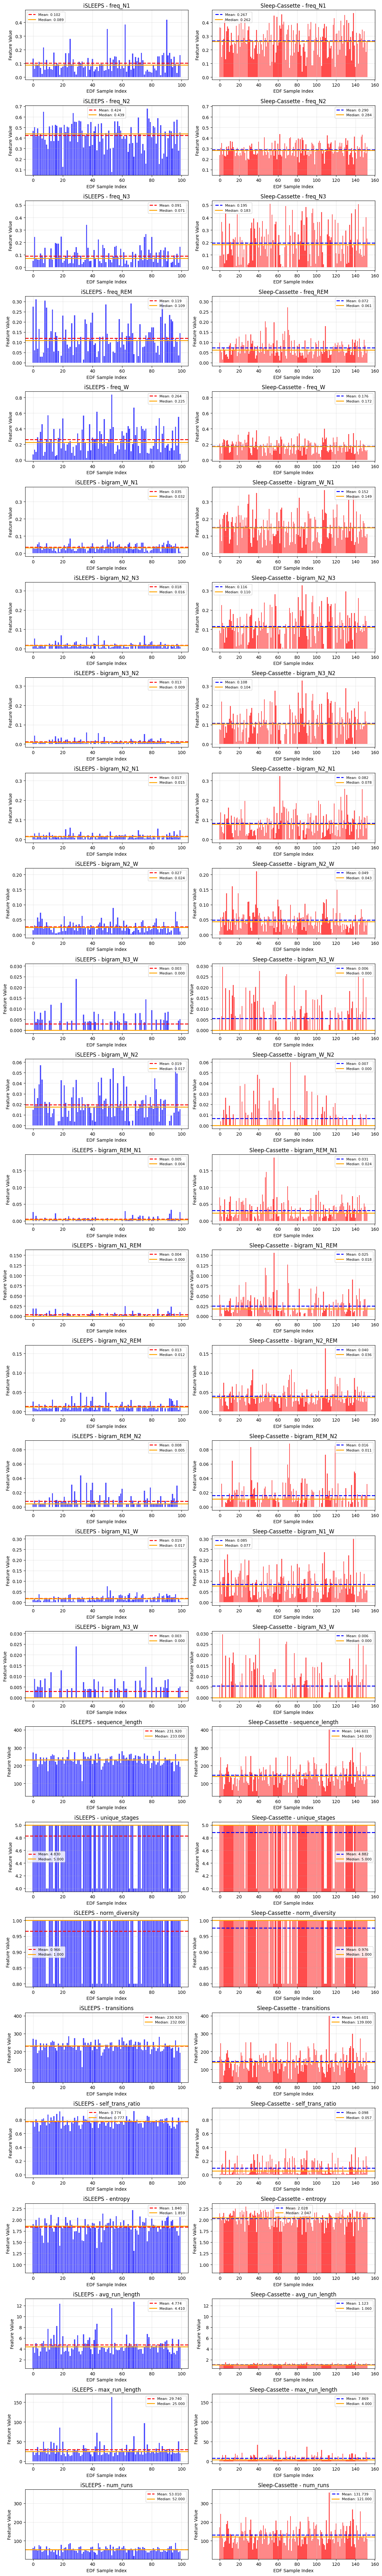

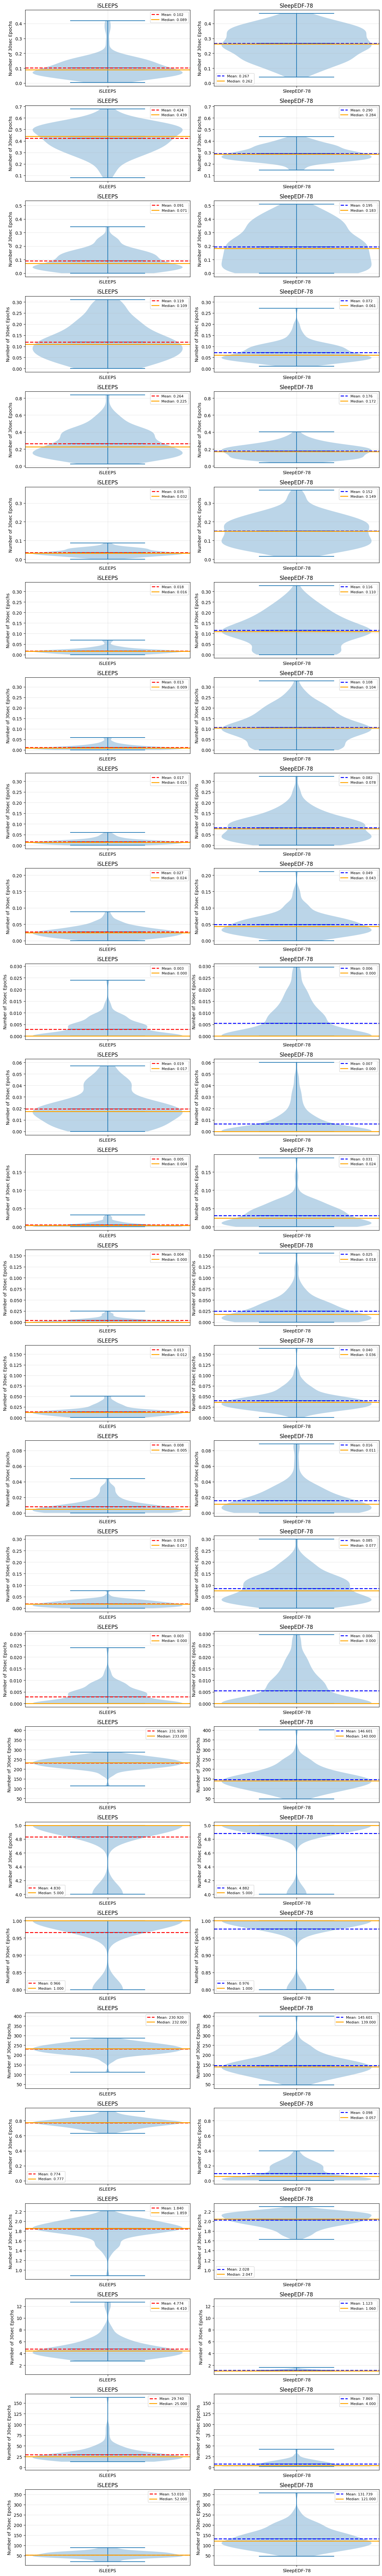

All plots saved successfully!


In [101]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.utils import shuffle
import os

import matplotlib.pyplot as plt

def extract_composition_features(sequence_list):
    """Extract comprehensive composition features from sequences"""
    features = []
    
    # Get all unique stages
    all_stages = sorted(set(stage for seq in sequence_list for stage in seq))
    
    for seq in sequence_list:
        seq_features = []
        total_length = len(seq)
        
        # 1. Symbol frequencies
        counts = Counter(seq)
        # Add stage frequencies separately for easy commenting
        seq_features.append(counts.get('N1', 0) / total_length)
        seq_features.append(counts.get('N2', 0) / total_length)
        seq_features.append(counts.get('N3', 0) / total_length)
        seq_features.append(counts.get('REM', 0) / total_length)
        seq_features.append(counts.get('W', 0) / total_length)
        
        # 2. Bigram frequencies
        bigrams = [tuple(seq[i:i+2]) for i in range(len(seq)-1)]
        bigram_counts = Counter(bigrams)
        
        # Get most common bigrams across all sequences and add them separately
        common_bigrams = [('W', 'N1'), ('N2', 'N3'), ('N3', 'N2'), 
                 ('N2', 'N1'), ('N2', 'W'), ('N3', 'W'),
                 ('W', 'N2'), ('REM', 'N1'), ('N1', 'REM'), ('N2', 'REM'),
                 ('REM', 'N2'), ('N1', 'W'), ('N3', 'W')]
        
        # Add each bigram feature separately for easier commenting/removal
        seq_features.append(bigram_counts.get(('W', 'N1'), 0) / max(1, len(bigrams)))
        seq_features.append(bigram_counts.get(('N2', 'N3'), 0) / max(1, len(bigrams)))
        seq_features.append(bigram_counts.get(('N3', 'N2'), 0) / max(1, len(bigrams)))
        seq_features.append(bigram_counts.get(('N2', 'N1'), 0) / max(1, len(bigrams)))
        seq_features.append(bigram_counts.get(('N2', 'W'), 0) / max(1, len(bigrams)))
        seq_features.append(bigram_counts.get(('N3', 'W'), 0) / max(1, len(bigrams)))
        seq_features.append(bigram_counts.get(('W', 'N2'), 0) / max(1, len(bigrams)))
        seq_features.append(bigram_counts.get(('REM', 'N1'), 0) / max(1, len(bigrams)))
        seq_features.append(bigram_counts.get(('N1', 'REM'), 0) / max(1, len(bigrams)))
        seq_features.append(bigram_counts.get(('N2', 'REM'), 0) / max(1, len(bigrams)))
        seq_features.append(bigram_counts.get(('REM', 'N2'), 0) / max(1, len(bigrams)))
        seq_features.append(bigram_counts.get(('N1', 'W'), 0) / max(1, len(bigrams)))
        seq_features.append(bigram_counts.get(('N3', 'W'), 0) / max(1, len(bigrams)))
        
        # 3. Sequence length
        seq_features.append(total_length)
        
        # 4. Diversity measures
        unique_stages = len(set(seq))
        seq_features.append(unique_stages)
        seq_features.append(unique_stages / 5)  # normalized diversity
        
        # 5. Transition counts
        transitions = len(bigrams)
        seq_features.append(transitions)
        
        # 6. Self-transition ratio
        self_transitions = sum(1 for i in range(len(seq)-1) if seq[i] == seq[i+1])
        seq_features.append(self_transitions / max(1, transitions))
        
        # 7. Stage distribution entropy
        if total_length > 0:
            probs = [counts.get(stage, 0) / total_length for stage in all_stages]
            entropy = -sum(p * np.log2(p) for p in probs if p > 0)
            seq_features.append(entropy)
        else:
            seq_features.append(0)
        
        # 8. Run lengths (consecutive same stages)
        runs = []
        current_run = 1
        for i in range(1, len(seq)):
            if seq[i] == seq[i-1]:
                current_run += 1
            else:
                runs.append(current_run)
                current_run = 1
        runs.append(current_run)
        
        seq_features.append(np.mean(runs))  # average run length
        seq_features.append(np.max(runs))   # max run length
        seq_features.append(len(runs))      # number of runs
        
        features.append(seq_features)
    
    return np.array(features)

# Extract features for both datasets
print("=== EXTRACTING COMPOSITION FEATURES ===")
features_isleeps = extract_composition_features(isleeps_value_lists)
features_sc = extract_composition_features(sc_value_lists)

print(f"iSLEEPS features shape: {features_isleeps.shape}")
print(f"Sleep-Cassette features shape: {features_sc.shape}")

# Create labels (0 for iSLEEPS, 1 for Sleep-Cassette)
labels_isleeps = np.zeros(len(features_isleeps))
labels_sc = np.ones(len(features_sc))

# Combine features and labels
X = np.vstack([features_isleeps, features_sc])
y = np.hstack([labels_isleeps, labels_sc])

# Randomly shuffle X and y while maintaining correspondence
X, y = shuffle(X, y, random_state=42)

print(f"Combined dataset shape: {X.shape}")
print(f"Class distribution: iSLEEPS={np.sum(y==0)}, Sleep-Cassette={np.sum(y==1)}")

# Feature names for interpretation
feature_names = [
    'freq_N1',
    'freq_N2',
    'freq_N3',
    'freq_REM',
    'freq_W',
    'bigram_W_N1',
    'bigram_N2_N3',
    'bigram_N3_N2',
    'bigram_N2_N1',
    'bigram_N2_W',
    'bigram_N3_W',
    'bigram_W_N2',
    'bigram_REM_N1',
    'bigram_N1_REM',
    'bigram_N2_REM',
    'bigram_REM_N2',
    'bigram_N1_W',
    'bigram_N3_W',
    'sequence_length',
    'unique_stages',
    'norm_diversity',
    'transitions',
    'self_trans_ratio',
    'entropy',
    'avg_run_length',
    'max_run_length',
    'num_runs'
]

# Create feature distribution plots
n_features = X.shape[1]
n_cols = 2  # Two columns: iSLEEPS and Sleep-Cassette
n_rows = n_features

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3*n_features))
if n_features == 1:
    axes = axes.reshape(1, -1)

# Split features back into original groups
features_isleeps_plot = X[y == 0]
features_sc_plot = X[y == 1]

os.makedirs('feature_distributions/individual_plots', exist_ok=True)
os.makedirs('feature_distributions/individual_plots/bar_plots', exist_ok=True)
os.makedirs('feature_distributions/individual_plots/violin_plots', exist_ok=True)
os.makedirs('feature_distributions', exist_ok=True)

for i in range(n_features):
    # Calculate statistics for consistent y-axis scaling
    isleeps_data = features_isleeps_plot[:, i]
    sc_data = features_sc_plot[:, i]
    
    # Get global min/max for consistent y-axis
    global_min = min(np.min(isleeps_data), np.min(sc_data))
    global_max = max(np.max(isleeps_data), np.max(sc_data))
    y_range = global_max - global_min
    y_min = global_min - 0.05 * y_range
    y_max = global_max + 0.05 * y_range
    
    # Calculate means and medians
    isleeps_mean = np.mean(isleeps_data)
    isleeps_median = np.median(isleeps_data)
    sc_mean = np.mean(sc_data)
    sc_median = np.median(sc_data)
    
    # iSLEEPS subplot (left)
    axes[i, 0].bar(range(len(features_isleeps_plot)), isleeps_data, alpha=0.7, color='blue')
    axes[i, 0].axhline(y=isleeps_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {isleeps_mean:.3f}')
    axes[i, 0].axhline(y=isleeps_median, color='orange', linestyle='-', linewidth=2, label=f'Median: {isleeps_median:.3f}')
    axes[i, 0].set_title(f'iSLEEPS - {feature_names[i]}')
    axes[i, 0].set_xlabel('EDF Sample Index')
    axes[i, 0].set_ylabel('Feature Value')
    axes[i, 0].set_ylim(y_min, y_max)
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].legend(fontsize=8)
    
    # Sleep-Cassette subplot (right)
    axes[i, 1].bar(range(len(features_sc_plot)), sc_data, alpha=0.7, color='red')
    axes[i, 1].axhline(y=sc_mean, color='blue', linestyle='--', linewidth=2, label=f'Mean: {sc_mean:.3f}')
    axes[i, 1].axhline(y=sc_median, color='orange', linestyle='-', linewidth=2, label=f'Median: {sc_median:.3f}')
    axes[i, 1].set_title(f'Sleep-Cassette - {feature_names[i]}')
    axes[i, 1].set_xlabel('EDF Sample Index')
    axes[i, 1].set_ylabel('Feature Value')
    axes[i, 1].set_ylim(y_min, y_max)
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('feature_distributions/bar_plots_all_features.png', dpi=300, bbox_inches='tight')
plt.show()

# Create violin plots for feature distributions
n_features = X.shape[1]
n_cols = 2  # Two columns: iSLEEPS and Sleep-Cassette
n_rows = n_features

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3*n_features))
if n_features == 1:
    axes = axes.reshape(1, -1)

# Split features back into original groups
features_isleeps_violin = X[y == 0]
features_sc_violin = X[y == 1]

for i in range(n_features):
    # Calculate statistics for consistent y-axis scaling
    isleeps_data = features_isleeps_violin[:, i]
    sc_data = features_sc_violin[:, i]
    
    # Get global min/max for consistent y-axis
    global_min = min(np.min(isleeps_data), np.min(sc_data))
    global_max = max(np.max(isleeps_data), np.max(sc_data))
    y_range = global_max - global_min
    y_min = global_min - 0.05 * y_range
    y_max = global_max + 0.05 * y_range
    
    # Calculate means and medians
    isleeps_mean = np.mean(isleeps_data)
    isleeps_median = np.median(isleeps_data)
    sc_mean = np.mean(sc_data)
    sc_median = np.median(sc_data)
    
    # iSLEEPS violin plot (left)
    axes[i, 0].violinplot(features_isleeps_violin[:, i], positions=[0], showmeans=True, showmedians=True)
    axes[i, 0].axhline(y=isleeps_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {isleeps_mean:.3f}')
    axes[i, 0].axhline(y=isleeps_median, color='orange', linestyle='-', linewidth=2, label=f'Median: {isleeps_median:.3f}')
    axes[i, 0].set_title(f'iSLEEPS')
    axes[i, 0].set_ylabel('Number of 30sec Epochs')
    axes[i, 0].set_ylim(y_min, y_max)
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].set_xticks([0])
    axes[i, 0].set_xticklabels(['iSLEEPS'])
    axes[i, 0].legend(fontsize=8)
    
    # Sleep-Cassette violin plot (right)
    axes[i, 1].violinplot(features_sc_violin[:, i], positions=[0], showmeans=True, showmedians=True)
    axes[i, 1].axhline(y=sc_mean, color='blue', linestyle='--', linewidth=2, label=f'Mean: {sc_mean:.3f}')
    axes[i, 1].axhline(y=sc_median, color='orange', linestyle='-', linewidth=2, label=f'Median: {sc_median:.3f}')
    axes[i, 1].set_title(f'SleepEDF-78')
    axes[i, 1].set_ylabel('Number of 30sec Epochs')
    axes[i, 1].set_ylim(y_min, y_max)
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].set_xticks([0])
    axes[i, 1].set_xticklabels(['SleepEDF-78'])
    axes[i, 1].legend(fontsize=8)


# Create individual plots for each feature and save them in a directory structure
plt.tight_layout()
plt.savefig('feature_distributions/violin_plots_all_features.png', dpi=300, bbox_inches='tight')
plt.show()

for i, feature_name in enumerate(feature_names):
    # Individual bar plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Calculate statistics for consistent y-axis scaling
    isleeps_data = features_isleeps_plot[:, i]
    sc_data = features_sc_plot[:, i]
    
    # Get global min/max for consistent y-axis
    global_min = min(np.min(isleeps_data), np.min(sc_data))
    global_max = max(np.max(isleeps_data), np.max(sc_data))
    y_range = global_max - global_min
    y_min = global_min - 0.05 * y_range
    y_max = global_max + 0.05 * y_range
    
    # Calculate means and medians
    isleeps_mean = np.mean(isleeps_data)
    isleeps_median = np.median(isleeps_data)
    sc_mean = np.mean(sc_data)
    sc_median = np.median(sc_data)
    
    # iSLEEPS bar plot
    axes[0].bar(range(len(features_isleeps_plot)), isleeps_data, alpha=0.7, color='blue')
    axes[0].axhline(y=isleeps_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {isleeps_mean:.3f}')
    axes[0].axhline(y=isleeps_median, color='orange', linestyle='-', linewidth=2, label=f'Median: {isleeps_median:.3f}')
    axes[0].set_title(f'iSLEEPS')
    axes[0].set_xlabel('Sample Number')
    axes[0].set_ylabel('Value')
    axes[0].set_ylim(y_min, y_max)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)
    
    # Sleep-Cassette bar plot
    axes[1].bar(range(len(features_sc_plot)), sc_data, alpha=0.7, color='red')
    axes[1].axhline(y=sc_mean, color='blue', linestyle='--', linewidth=2, label=f'Mean: {sc_mean:.3f}')
    axes[1].axhline(y=sc_median, color='orange', linestyle='-', linewidth=2, label=f'Median: {sc_median:.3f}')
    axes[1].set_title(f'SleepEDF-78')
    axes[1].set_xlabel('Sample Number')
    axes[1].set_ylabel('Value')
    axes[1].set_ylim(y_min, y_max)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=8)
    
    plt.tight_layout()
    plt.savefig(f'feature_distributions/individual_plots/bar_plots/{feature_name}_bar.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # Individual violin plots
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    
    # Calculate statistics for consistent y-axis scaling
    isleeps_data = features_isleeps_violin[:, i]
    sc_data = features_sc_violin[:, i]
    
    # Get global min/max for consistent y-axis
    global_min = min(np.min(isleeps_data), np.min(sc_data))
    global_max = max(np.max(isleeps_data), np.max(sc_data))
    y_range = global_max - global_min
    y_min = global_min - 0.05 * y_range
    y_max = global_max + 0.05 * y_range
    
    # Calculate means and medians
    isleeps_mean = np.mean(isleeps_data)
    isleeps_median = np.median(isleeps_data)
    sc_mean = np.mean(sc_data)
    sc_median = np.median(sc_data)
    
    # iSLEEPS violin plot
    axes[0].violinplot(features_isleeps_violin[:, i], positions=[0], showmeans=True, showmedians=True)
    axes[0].axhline(y=isleeps_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {isleeps_mean:.3f}')
    axes[0].axhline(y=isleeps_median, color='orange', linestyle='-', linewidth=2, label=f'Median: {isleeps_median:.3f}')
    axes[0].set_ylabel('Number of 30sec Epochs')
    axes[0].set_ylim(y_min, y_max)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks([0])
    axes[0].set_xticklabels(['iSLEEPS'])
    axes[0].legend(fontsize=8)
    
    # Sleep-Cassette violin plot
    axes[1].violinplot(features_sc_violin[:, i], positions=[0], showmeans=True, showmedians=True)
    axes[1].axhline(y=sc_mean, color='blue', linestyle='--', linewidth=2, label=f'Mean: {sc_mean:.3f}')
    axes[1].axhline(y=sc_median, color='orange', linestyle='-', linewidth=2, label=f'Median: {sc_median:.3f}')
    axes[1].set_ylabel('Number of 30sec Epochs')
    axes[1].set_ylim(y_min, y_max)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks([0])
    axes[1].set_xticklabels(['SleepEDF-78'])
    axes[1].legend(fontsize=8)
    
    # Add overall title to the figure
    if feature_name == "avg_run_length":
        fig.suptitle("Average Run Length Comparison", fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.savefig(f'feature_distributions/individual_plots/violin_plots/{feature_name}_violin.png', dpi=300, bbox_inches='tight')
    plt.close()

print("All plots saved successfully!")

In [56]:
# Define which features to use (comment out features you want to exclude)
use_features = {
    # Symbol frequencies
    'freq_N1': False,
    'freq_N2': False,
    'freq_N3': False,
    'freq_REM': False,
    'freq_W': False,
    
    # Bigram frequencies
    'bigram_W_N1': False,
    'bigram_N2_N3': False,
    'bigram_N3_N2': False,
    'bigram_N2_N1': False,
    'bigram_N2_W': False,
    'bigram_N3_W': False,
    'bigram_W_N2': False,
    'bigram_REM_N1': False,
    'bigram_N1_REM': False,
    'bigram_N2_REM': False,
    'bigram_REM_N2': False,
    'bigram_N1_W': False,
    'bigram_N3_W': False,
    
    # Sequence statistics
    'sequence_length': False,
    'unique_stages': False,
    'norm_diversity': False,
    'transitions': False,
    'self_trans_ratio': False,
    'entropy': False,
    'avg_run_length': True,
    'max_run_length': False,
    'num_runs': False
}

# Filter features and feature names based on user selection
selected_indices = [i for i, name in enumerate(feature_names) if use_features.get(name, False)]
selected_feature_names = [name for name in feature_names if use_features.get(name, False)]

# Apply feature selection to the data
X_selected = X[:, selected_indices]

print(f"Using {len(selected_indices)} out of {len(feature_names)} features:")
for name in selected_feature_names:
    print(f"  - {name}")

# Update X to use only selected features
X = X_selected
feature_names = selected_feature_names

print(f"\nUpdated dataset shape: {X.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train multiple classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42, probability=True)
}

print("\n=== CLASSIFIER PERFORMANCE ===")
results = {}

# Calculate means for each dataset (for comparison)
isleeps_means = np.mean(features_isleeps, axis=0)
sc_means = np.mean(features_sc, axis=0)
differences = sc_means - isleeps_means

for name, clf in classifiers.items():
    print(f"\n{name}:")
    
    # Train classifier
    if name == 'SVM':
        clf.fit(X_train_scaled, y_train)
        y_pred = clf.predict(X_test_scaled)
        y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1]
        
        # Cross-validation with scaled data
        cv_scores = cross_val_score(clf, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    else:
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_pred_proba = clf.predict_proba(X_test)[:, 1]
        
        # Cross-validation
        cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='roc_auc')
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC AUC: {roc_auc:.4f}")
    print(f"  CV ROC AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    # Classification report
    print(f"  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['iSLEEPS', 'Sleep-Cassette'], 
                                zero_division=0, output_dict=False))
    
    # Confusion matrix
    print(f"  Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(f"  {cm}")
    
    results[name] = {
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'cv_auc_mean': cv_scores.mean(),
        'cv_auc_std': cv_scores.std(),
        'model': clf,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'confusion_matrix': cm
    }
    
    # Feature analysis for each model
    print(f"\n=== FEATURE ANALYSIS - {name} ===")
    print("=" * 80)
    
    # Feature importance (for tree-based models)
    if hasattr(clf, 'feature_importances_'):
        feature_importance = clf.feature_importances_
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': feature_importance
        }).sort_values('importance', ascending=False)
        
        print(f"Features Ranked by Importance:")
        print("-" * 80)
        print(f"{'Rank':<4} {'Feature':<20} {'Importance':<12} {'iSLEEPS Mean':<12} {'SC Mean':<12} {'Difference'}")
        print("-" * 80)
        
        for idx, row in importance_df.iterrows():
            feature = row['feature']
            importance = row['importance']
            rank = importance_df.index.get_loc(idx) + 1
            feat_idx = feature_names.index(feature)
            isleeps_val = isleeps_means[feat_idx]
            sc_val = sc_means[feat_idx]
            diff = sc_val - isleeps_val
            
            print(f"{rank:<4} {feature:<20} {importance:<12.6f} {isleeps_val:<12.4f} {sc_val:<12.4f} {diff:<12.4f}")

    # Coefficient analysis (for logistic regression)
    elif hasattr(clf, 'coef_'):
        coefficients = clf.coef_[0]
        coef_df = pd.DataFrame({
            'feature': feature_names,
            'coefficient': coefficients,
            'abs_coefficient': np.abs(coefficients)
        }).sort_values('abs_coefficient', ascending=False)
        
        print(f"Features Ranked by Coefficient Magnitude:")
        print("-" * 80)
        print(f"{'Rank':<4} {'Feature':<20} {'Coefficient':<12} {'iSLEEPS Mean':<12} {'SC Mean':<12} {'Difference'}")
        print("-" * 80)
        
        for idx, row in coef_df.iterrows():
            feature = row['feature']
            coef = row['coefficient']
            rank = coef_df.index.get_loc(idx) + 1
            feat_idx = feature_names.index(feature)
            isleeps_val = isleeps_means[feat_idx]
            sc_val = sc_means[feat_idx]
            diff = sc_val - isleeps_val
            
            print(f"{rank:<4} {feature:<20} {coef:<12.4f} {isleeps_val:<12.4f} {sc_val:<12.4f} {diff:<12.4f}")
    
    print("\n" + "="*80)

# Overall comparison
print(f"\n=== OVERALL MODEL COMPARISON ===")
print("=" * 100)
print(f"{'Model':<20} {'Accuracy':<10} {'ROC AUC':<10} {'CV AUC Mean':<12} {'CV AUC Std':<12}")
print("-" * 100)

for name, result in results.items():
    print(f"{name:<20} {result['accuracy']:<10.4f} {result['roc_auc']:<10.4f} "
          f"{result['cv_auc_mean']:<12.4f} {result['cv_auc_std']:<12.4f}")

# Best model summary
best_model_name = max(results.keys(), key=lambda k: results[k]['roc_auc'])
print(f"\nBest performing model: {best_model_name}")
print(f"Best ROC AUC: {results[best_model_name]['roc_auc']:.4f}")

# Dataset comparison by feature
print(f"\n=== DATASET COMPARISON BY FEATURE ===")
print("=" * 100)
print(f"{'Feature':<20} {'iSLEEPS Mean':<15} {'Sleep-Cass Mean':<15} {'Difference':<12} {'Interpretation'}")
print("-" * 100)

for i, feature in enumerate(feature_names):
    isleeps_mean = isleeps_means[i]
    sc_mean = sc_means[i]
    diff = differences[i]
    
    # Interpretation based on difference
    if abs(diff) < 0.001:
        interpretation = "Very similar"
    elif diff > 0:
        interpretation = f"Higher in SC (+{diff:.4f})"
    else:
        interpretation = f"Higher in iSLEEPS ({diff:.4f})"
    
    print(f"{feature:<20} {isleeps_mean:<15.4f} {sc_mean:<15.4f} {diff:<12.4f} {interpretation}")

Using 1 out of 27 features:
  - avg_run_length

Updated dataset shape: (253, 1)

=== CLASSIFIER PERFORMANCE ===

Logistic Regression:
  Accuracy: 1.0000
  ROC AUC: 1.0000
  CV ROC AUC: 1.0000 ± 0.0000
  Classification Report:
                precision    recall  f1-score   support

       iSLEEPS       1.00      1.00      1.00        30
Sleep-Cassette       1.00      1.00      1.00        46

      accuracy                           1.00        76
     macro avg       1.00      1.00      1.00        76
  weighted avg       1.00      1.00      1.00        76

  Confusion Matrix:
  [[30  0]
 [ 0 46]]

=== FEATURE ANALYSIS - Logistic Regression ===
Features Ranked by Coefficient Magnitude:
--------------------------------------------------------------------------------
Rank Feature              Coefficient  iSLEEPS Mean SC Mean      Difference
--------------------------------------------------------------------------------
1    avg_run_length       -3.2307      0.1024       0.2665       0

In [57]:
import itertools
from collections import defaultdict
import time
import numpy as np
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

def test_all_feature_combinations():
    """Test all possible combinations of features and return results"""
    
    # Get original feature data (before any selection was applied)
    original_features_isleeps = extract_composition_features(isleeps_value_lists)
    original_features_sc = extract_composition_features(sc_value_lists)
    
    # Create labels
    labels_isleeps = np.zeros(len(original_features_isleeps))
    labels_sc = np.ones(len(original_features_sc))
    
    # Combine features and labels
    X_full = np.vstack([original_features_isleeps, original_features_sc])
    y_full = np.hstack([labels_isleeps, labels_sc])
    
    # Shuffle data
    X_full, y_full = shuffle(X_full, y_full, random_state=42)
    
    # Original feature names
    original_feature_names = [
        # Sleep stage frequencies - proportion of time spent in each stage
        'freq_N1',        # Light sleep frequency - transition stage, indicates sleep onset/fragmentation
        'freq_N2',        # Stable NREM sleep - main restorative sleep stage
        'freq_N3',        # Deep sleep frequency - critical for physical recovery and memory consolidation
        'freq_REM',       # REM sleep frequency - important for emotional processing and learning
        'freq_W',         # Wake frequency - indicates sleep disruption and fragmentation
        
        # Bigram transitions - sleep stage transition patterns (2-stage sequences)
        'bigram_W_N1',    # Wake to N1 - normal sleep onset pattern
        'bigram_N2_N3',   # N2 to N3 - deepening of sleep, healthy pattern
        'bigram_N3_N2',   # N3 to N2 - lightening from deep sleep, normal cycle
        'bigram_N2_N1',   # N2 to N1 - sleep lightening, possible arousal
        'bigram_N2_W',    # N2 to Wake - mid-sleep awakening, disrupted sleep
        'bigram_N3_W',    # N3 to Wake - awakening from deep sleep, unusual pattern
        'bigram_W_N2',    # Wake to N2 - direct entry to stable sleep after awakening
        'bigram_REM_N1',  # REM to N1 - normal REM cycle ending
        'bigram_N1_REM',  # N1 to REM - unusual direct transition to REM
        'bigram_N2_REM',  # N2 to REM - normal REM cycle initiation
        'bigram_REM_N2',  # REM to N2 - return to NREM after REM
        'bigram_N1_W',    # N1 to Wake - light sleep to awakening, possible arousal
        'bigram_N3_W',    # N3 to Wake - awakening from deep sleep, unusual pattern
        
        # Sleep architecture metrics - overall sleep structure characteristics
        'sequence_length',   # Total sleep period duration - indicates sleep opportunity
        'unique_stages',     # Number of different sleep stages present - sleep complexity
        'norm_diversity',    # Sleep stage diversity index - balanced vs. unbalanced sleep
        'transitions',       # Total number of stage transitions - sleep stability measure
        'self_trans_ratio',  # Proportion of staying in same stage - sleep continuity
        'entropy',          # Sleep pattern randomness - higher = more fragmented/unpredictable
        'avg_run_length',   # Average duration in each stage - sleep stage stability
        'max_run_length',   # Longest continuous stage duration - deepest sleep indicator
        'num_runs'          # Number of stage runs - sleep fragmentation measure
    ]
    
    # Store results for all combinations
    all_results = []
    
    # Test individual features first
    print("=== TESTING INDIVIDUAL FEATURES ===")
    for i, feature_name in enumerate(original_feature_names):
        print(f"Testing feature: {feature_name}")
        
        X_single = X_full[:, [i]]
        X_train, X_test, y_train, y_test = train_test_split(X_single, y_full, test_size=0.3, 
                                                           random_state=42, stratify=y_full)
        
        # Test with Random Forest (generally robust)
        clf = RandomForestClassifier(random_state=42, n_estimators=100)
        clf.fit(X_train, y_train)
        y_pred_proba = clf.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        cv_scores = cross_val_score(clf, X_single, y_full, cv=5, scoring='roc_auc')
        
        result = {
            'features': [feature_name],
            'num_features': 1,
            'roc_auc': roc_auc,
            'cv_auc_mean': cv_scores.mean(),
            'cv_auc_std': cv_scores.std(),
            'feature_indices': [i]
        }
        all_results.append(result)

    # Identify features that achieve perfect ROC-AUC (1.00) individually
    perfect_features = []
    single_feature_results = [r for r in all_results if r['num_features'] == 1]

    for result in single_feature_results:
        if result['roc_auc'] >= 1.0 or result['cv_auc_mean'] >= 1.0:
            perfect_features.extend(result['feature_indices'])

    print(f"\nFeatures with perfect individual performance: {[original_feature_names[i] for i in perfect_features]}")
    
    # Test combinations of 2 features
    print("\n=== TESTING 2-FEATURE COMBINATIONS ===")
    n_features = len(original_feature_names)
    
    for combo in itertools.combinations(range(n_features), 2):
        feature_names_combo = [original_feature_names[i] for i in combo]
        print(f"Testing features: {feature_names_combo}")
        
        X_combo = X_full[:, list(combo)]
        X_train, X_test, y_train, y_test = train_test_split(X_combo, y_full, test_size=0.3, 
                                                           random_state=42, stratify=y_full)
        
        # Test with Random Forest
        clf = RandomForestClassifier(random_state=42, n_estimators=100)
        clf.fit(X_train, y_train)
        y_pred_proba = clf.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        cv_scores = cross_val_score(clf, X_combo, y_full, cv=5, scoring='roc_auc')
        
        if set(combo).intersection(set(perfect_features)):
            result = {
                'features': feature_names_combo,
                'num_features': 2,
                'roc_auc': roc_auc,
                'cv_auc_mean': cv_scores.mean(),
                'cv_auc_std': cv_scores.std(),
                'feature_indices': list(combo),
                'excludes_perfect': False
            }
        else:
            result = {
                'features': feature_names_combo,
                'num_features': 2,
                'roc_auc': roc_auc,
                'cv_auc_mean': cv_scores.mean(),
                'cv_auc_std': cv_scores.std(),
                'feature_indices': list(combo),
                'excludes_perfect': True
            }
        all_results.append(result)
    
    # Sort 2-feature results and take top 20
    two_feature_results = [r for r in all_results if r['num_features'] == 2]
    two_feature_results.sort(key=lambda x: x['cv_auc_mean'], reverse=True)
    top_two_features = two_feature_results[:20]
    
    # Get unique features from top combinations
    top_feature_indices = set()
    for result in top_two_features:
        top_feature_indices.update(result['feature_indices'])

    # Identify 2-feature combinations that achieve perfect ROC-AUC (1.00)
    perfect_two_feature_combos = []
    two_feature_results = [r for r in all_results if r['num_features'] == 2]

    for result in two_feature_results:
        if result['roc_auc'] >= 1.0 or result['cv_auc_mean'] >= 1.0:
            perfect_two_feature_combos.append(set(result['feature_indices']))

    print(f"Found {len(perfect_two_feature_combos)} perfect 2-feature combinations")
    for combo in perfect_two_feature_combos:
        combo_names = [original_feature_names[i] for i in combo]
        print(f"  Perfect 2-feature combo: {combo_names}")
    
    # Test combinations of 3 features (top performing ones from 2-feature combinations)
    print("\n=== TESTING 3-FEATURE COMBINATIONS ===")

    # Function to check if a 3-feature combination contains any perfect 2-feature subset
    def contains_perfect_subset(three_feature_combo, perfect_two_combos):
        three_set = set(three_feature_combo)
        for perfect_two in perfect_two_combos:
            if perfect_two.issubset(three_set):
                return True
        return False

    # Test 3-feature combinations that don't contain perfect 2-feature subsets
    valid_three_combos = []
    other_three_combos = []
    excluded_count = 0

    for combo in itertools.combinations(range(n_features), 3):
        if not contains_perfect_subset(combo, perfect_two_feature_combos):
            valid_three_combos.append(combo)
        else:
            other_three_combos.append(combo)
            excluded_count += 1

    print(f"Testing {len(valid_three_combos)} 3-feature combinations")
    print(f"Found {excluded_count} combinations containing perfect 2-feature subsets")

    for combo in valid_three_combos:
        feature_names_combo = [original_feature_names[i] for i in combo]
        print(f"Testing features: {feature_names_combo}")
        
        X_combo = X_full[:, list(combo)]
        X_train, X_test, y_train, y_test = train_test_split(X_combo, y_full, test_size=0.3, 
                                                           random_state=42, stratify=y_full)
        
        # Test with Random Forest
        clf = RandomForestClassifier(random_state=42, n_estimators=100)
        clf.fit(X_train, y_train)
        y_pred_proba = clf.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        cv_scores = cross_val_score(clf, X_combo, y_full, cv=5, scoring='roc_auc')
        
        result = {
            'features': feature_names_combo,
            'num_features': 3,
            'roc_auc': roc_auc,
            'cv_auc_mean': cv_scores.mean(),
            'cv_auc_std': cv_scores.std(),
            'feature_indices': list(combo),
            'excludes_perfect_subsets': True
        }
        all_results.append(result)

    for combo in other_three_combos:
        feature_names_combo = [original_feature_names[i] for i in combo]
        print(f"Testing features: {feature_names_combo}")
        
        X_combo = X_full[:, list(combo)]
        X_train, X_test, y_train, y_test = train_test_split(X_combo, y_full, test_size=0.3, 
                                                           random_state=42, stratify=y_full)
        
        # Test with Random Forest
        clf = RandomForestClassifier(random_state=42, n_estimators=100)
        clf.fit(X_train, y_train)
        y_pred_proba = clf.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        cv_scores = cross_val_score(clf, X_combo, y_full, cv=5, scoring='roc_auc')
        
        result = {
            'features': feature_names_combo,
            'num_features': 3,
            'roc_auc': roc_auc,
            'cv_auc_mean': cv_scores.mean(),
            'cv_auc_std': cv_scores.std(),
            'feature_indices': list(combo),
            'excludes_perfect_subsets': False
        }
        all_results.append(result)
    
    return all_results, original_feature_names, X_full, y_full

In [58]:
# Run comprehensive analysis
print("Starting comprehensive feature combination analysis...")
start_time = time.time()

all_results, original_feature_names, X_full, y_full = test_all_feature_combinations()

end_time = time.time()
print(f"Analysis completed in {end_time - start_time:.2f} seconds")

Starting comprehensive feature combination analysis...
=== TESTING INDIVIDUAL FEATURES ===
Testing feature: freq_N1
Testing feature: freq_N2
Testing feature: freq_N2
Testing feature: freq_N3
Testing feature: freq_N3
Testing feature: freq_REM
Testing feature: freq_REM
Testing feature: freq_W
Testing feature: freq_W
Testing feature: bigram_W_N1
Testing feature: bigram_W_N1
Testing feature: bigram_N2_N3
Testing feature: bigram_N2_N3
Testing feature: bigram_N3_N2
Testing feature: bigram_N3_N2
Testing feature: bigram_N2_N1
Testing feature: bigram_N2_N1
Testing feature: bigram_N2_W
Testing feature: bigram_N2_W
Testing feature: bigram_N3_W
Testing feature: bigram_N3_W
Testing feature: bigram_W_N2
Testing feature: bigram_W_N2
Testing feature: bigram_REM_N1
Testing feature: bigram_REM_N1
Testing feature: bigram_N1_REM
Testing feature: bigram_N1_REM
Testing feature: bigram_N2_REM
Testing feature: bigram_N2_REM
Testing feature: bigram_REM_N2
Testing feature: bigram_REM_N2
Testing feature: bigram_

In [59]:
from collections import Counter

# Show the features extracted for one sample as an example
print("=== FEATURE EXTRACTION EXAMPLE ===")
print("Showing features extracted for the first sample from iSLEEPS dataset")
print("-" * 80)

# Get the first sequence from iSLEEPS
sample_sequence = isleeps_value_lists[0]
print(f"Sample sequence: {sample_sequence}")
print(f"Sequence length: {len(sample_sequence)}")

# Extract features for just this one sample
sample_features = extract_composition_features([sample_sequence])

print(f"\nExtracted features for this sample:")
print("-" * 80)

for i, feature_name in enumerate(original_feature_names):
    feature_value = sample_features[0][i]
    print(f"{i+1:2d}. {feature_name:<20}: {feature_value:.6f}")

print(f"\nFeature vector shape: {sample_features.shape}")
print(f"Total number of features: {len(original_feature_names)}")

# Show some calculations for verification
print(f"\n=== MANUAL VERIFICATION ===")
print("-" * 40)

# Symbol frequencies
counts = Counter(sample_sequence)
total_length = len(sample_sequence)
print(f"Manual symbol frequency calculations:")
for stage in ['N1', 'N2', 'N3', 'REM', 'W']:
    freq = counts.get(stage, 0) / total_length
    print(f"  {stage}: {counts.get(stage, 0)}/{total_length} = {freq:.6f}")

# Bigram example
bigrams = [tuple(sample_sequence[i:i+2]) for i in range(len(sample_sequence)-1)]
bigram_counts = Counter(bigrams)
print(f"\nSample bigram calculations:")
print(f"  Total bigrams: {len(bigrams)}")
print(f"  Example - ('W', 'N1'): {bigram_counts.get(('W', 'N1'), 0)}/{len(bigrams)} = {bigram_counts.get(('W', 'N1'), 0) / max(1, len(bigrams)):.6f}")

# Sequence statistics
unique_stages = len(set(sample_sequence))
print(f"\nSequence statistics:")
print(f"  Unique stages: {unique_stages}")
print(f"  Normalized diversity: {unique_stages / 5:.6f}")  # 5 is total possible stages

# Run lengths
runs = []
current_run = 1
for i in range(1, len(sample_sequence)):
    if sample_sequence[i] == sample_sequence[i-1]:
        current_run += 1
    else:
        runs.append(current_run)
        current_run = 1
runs.append(current_run)

print(f"  Run lengths: {runs}")
print(f"  Average run length: {np.mean(runs):.6f}")
print(f"  Max run length: {np.max(runs):.6f}")
print(f"  Number of runs: {len(runs):.6f}")

=== FEATURE EXTRACTION EXAMPLE ===
Showing features extracted for the first sample from iSLEEPS dataset
--------------------------------------------------------------------------------
Sample sequence: ['W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'N2', 'N2', 'N2', 'W', 'W', 'N1', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N1', 'N2', 'W', 'W', 'N1', 'N1', 'N1', 'N1', 'N1', 'N1', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'N1', 'W', 'W', 'W', 'N1', 'W', 'W', 'W', 'W', 'W', 'W', 'N2', 'N2', 'N2', 'N2', 'N2', 'W', 'W', 'W', 'W', 'W', 'N1', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N3', 'N3', 'N3', 'N3', 'N3', 'N3', 'N2', 'N2', 'W', 'N1', 'N1', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'W', 'W', 'N2', 'W', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 

In [60]:
# Analyze results
print("\n" + "="*100)
print("COMPREHENSIVE FEATURE COMBINATION ANALYSIS RESULTS")
print("="*100)

# Group results by number of features
results_by_num_features = defaultdict(list)
for result in all_results:
    results_by_num_features[result['num_features']].append(result)

# Display top results for each category
for num_features in sorted(results_by_num_features.keys()):
    results = results_by_num_features[num_features]
    results.sort(key=lambda x: (x['cv_auc_mean'], x['roc_auc']), reverse=True)
    
    print(f"\n=== TOP 10 COMBINATIONS WITH {num_features} FEATURE(S) ===")
    print("-" * 120)
    print(f"{'Rank':<4} {'Features':<60} {'ROC AUC':<10} {'CV Mean':<10} {'CV Std':<10}")
    print("-" * 120)
    
    for i, result in enumerate(results[:10]):
        features_str = ', '.join(result['features'][:3])  # Show first 3 features
        if len(result['features']) > 3:
            features_str += '...'
        
        print(f"{i+1:<4} {features_str:<60} {result['roc_auc']:<10.4f} "
              f"{result['cv_auc_mean']:<10.4f} {result['cv_auc_std']:<10.4f}")
    
    # Show detailed view of top 3
    print(f"\nDETAILED VIEW - TOP 3 COMBINATIONS WITH {num_features} FEATURE(S):")
    print("-" * 120)
    
    for i, result in enumerate(results[:3]):
        print(f"\nRank {i+1}:")
        print(f"  Features: {result['features']}")
        print(f"  ROC AUC: {result['roc_auc']:.6f}")
        print(f"  CV AUC Mean: {result['cv_auc_mean']:.6f} ± {result['cv_auc_std']:.6f}")


COMPREHENSIVE FEATURE COMBINATION ANALYSIS RESULTS

=== TOP 10 COMBINATIONS WITH 1 FEATURE(S) ===
------------------------------------------------------------------------------------------------------------------------
Rank Features                                                     ROC AUC    CV Mean    CV Std    
------------------------------------------------------------------------------------------------------------------------
1    self_trans_ratio                                             1.0000     1.0000     0.0000    
2    avg_run_length                                               1.0000     1.0000     0.0000    
3    num_runs                                                     0.9486     0.9423     0.0187    
4    max_run_length                                               0.9580     0.9327     0.0148    
5    bigram_N2_N3                                                 0.9525     0.9311     0.0436    
6    bigram_W_N1                                                 

In [61]:
# Overall best combinations
print("\n" + "="*100)
print("OVERALL BEST FEATURE COMBINATIONS")
print("="*100)

all_results.sort(key=lambda x: (x['cv_auc_mean'], x['roc_auc']), reverse=True)

print(f"{'Rank':<4} {'# Feat':<7} {'Features':<50} {'ROC AUC':<10} {'CV Mean':<10} {'CV Std':<10}")
print("-" * 120)

for i, result in enumerate(all_results[:20]):
    features_str = ', '.join(result['features'][:2])  # Show first 2 features
    if len(result['features']) > 2:
        features_str += '...'
    
    print(f"{i+1:<4} {result['num_features']:<7} {features_str:<50} "
          f"{result['roc_auc']:<10.4f} {result['cv_auc_mean']:<10.4f} {result['cv_auc_std']:<10.4f}")


OVERALL BEST FEATURE COMBINATIONS
Rank # Feat  Features                                           ROC AUC    CV Mean    CV Std    
------------------------------------------------------------------------------------------------------------------------
1    2       bigram_N2_N3, self_trans_ratio                     1.0000     1.0000     0.0000    
2    2       bigram_N2_N3, avg_run_length                       1.0000     1.0000     0.0000    
3    1       self_trans_ratio                                   1.0000     1.0000     0.0000    
4    1       avg_run_length                                     1.0000     1.0000     0.0000    
5    2       freq_N1, self_trans_ratio                          1.0000     1.0000     0.0000    
6    2       freq_N1, avg_run_length                            1.0000     1.0000     0.0000    
7    2       freq_N3, self_trans_ratio                          1.0000     1.0000     0.0000    
8    2       freq_N3, avg_run_length                            1.00

In [62]:
# Feature frequency analysis
print(f"\n=== FEATURE IMPORTANCE ANALYSIS ===")
feature_performance = defaultdict(list)

for result in all_results:
    for feature in result['features']:
        feature_performance[feature].append(result['cv_auc_mean'])

# Calculate average performance for each feature
feature_avg_performance = {}
for feature, performances in feature_performance.items():
    feature_avg_performance[feature] = {
        'avg_performance': np.mean(performances),
        'std_performance': np.std(performances),
        'count': len(performances),
        'max_performance': np.max(performances)
    }

# Sort by average performance
sorted_features = sorted(feature_avg_performance.items(), 
                        key=lambda x: x[1]['avg_performance'], reverse=True)

print(f"{'Rank':<4} {'Feature':<20} {'Avg Perf':<12} {'Std':<12} {'Max Perf':<12} {'Count':<8}")
print("-" * 80)

for i, (feature, stats) in enumerate(sorted_features):
    print(f"{i+1:<4} {feature:<20} {stats['avg_performance']:<12.4f} "
          f"{stats['std_performance']:<12.4f} {stats['max_performance']:<12.4f} {stats['count']:<8}")


=== FEATURE IMPORTANCE ANALYSIS ===
Rank Feature              Avg Perf     Std          Max Perf     Count   
--------------------------------------------------------------------------------
1    self_trans_ratio     1.0000       0.0000       1.0000       352     
2    avg_run_length       1.0000       0.0000       1.0000       352     
3    num_runs             0.9862       0.0150       1.0000       352     
4    bigram_N2_N3         0.9843       0.0193       1.0000       352     
5    bigram_W_N1          0.9832       0.0196       1.0000       352     
6    max_run_length       0.9825       0.0170       1.0000       352     
7    bigram_N3_N2         0.9821       0.0214       1.0000       352     
8    transitions          0.9746       0.0281       1.0000       352     
9    sequence_length      0.9745       0.0282       1.0000       352     
10   bigram_N2_REM        0.9689       0.0344       1.0000       352     
11   freq_N1              0.9670       0.0343       1.0000       352

In [63]:
# Test the absolute best combination with all classifiers
print(f"\n=== DETAILED ANALYSIS OF BEST FEATURE COMBINATION ===")
best_result = all_results[0]
print(f"Best feature combination: {best_result['features']}")
print(f"CV AUC: {best_result['cv_auc_mean']:.6f} ± {best_result['cv_auc_std']:.6f}")

# Test with all classifiers
best_indices = best_result['feature_indices']
X_best = X_full[:, best_indices]

print(f"\nTesting best combination with all classifiers:")
print("-" * 80)

classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42, probability=True)
}

X_train, X_test, y_train, y_test = train_test_split(X_best, y_full, test_size=0.3, 
                                                   random_state=42, stratify=y_full)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for name, clf in classifiers.items():
    if name == 'SVM':
        clf.fit(X_train_scaled, y_train)
        y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1]
        cv_scores = cross_val_score(clf, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    else:
        clf.fit(X_train, y_train)
        y_pred_proba = clf.predict_proba(X_test)[:, 1]
        cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='roc_auc')
    
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"{name:<20} ROC AUC: {roc_auc:.4f}, CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print(f"\nAnalysis complete! Tested {len(all_results)} feature combinations.")


=== DETAILED ANALYSIS OF BEST FEATURE COMBINATION ===
Best feature combination: ['bigram_N2_N3', 'self_trans_ratio']
CV AUC: 1.000000 ± 0.000000

Testing best combination with all classifiers:
--------------------------------------------------------------------------------
Logistic Regression  ROC AUC: 1.0000, CV AUC: 1.0000 ± 0.0000
Decision Tree        ROC AUC: 1.0000, CV AUC: 1.0000 ± 0.0000
Random Forest        ROC AUC: 1.0000, CV AUC: 1.0000 ± 0.0000
SVM                  ROC AUC: 1.0000, CV AUC: 1.0000 ± 0.0000

Analysis complete! Tested 3303 feature combinations.
Random Forest        ROC AUC: 1.0000, CV AUC: 1.0000 ± 0.0000
SVM                  ROC AUC: 1.0000, CV AUC: 1.0000 ± 0.0000

Analysis complete! Tested 3303 feature combinations.


In [64]:
# Separate analysis for feature sets that exclude perfect performers
print("\n" + "="*100)
print("ANALYSIS OF FEATURE COMBINATIONS EXCLUDING PERFECT PERFORMERS")
print("="*100)

# Filter results for combinations that exclude perfect individual features
excludes_perfect_results = [r for r in all_results if r.get('excludes_perfect', False)]

if excludes_perfect_results:
    print(f"\n=== FEATURE COMBINATIONS EXCLUDING PERFECT INDIVIDUAL FEATURES ({len(excludes_perfect_results)} combinations) ===")
    excludes_perfect_results.sort(key=lambda x: x['cv_auc_mean'], reverse=True)
    
    print(f"{'Rank':<4} {'Features':<60} {'ROC AUC':<10} {'CV Mean':<10} {'CV Std':<10}")
    print("-" * 120)
    
    for i, result in enumerate(excludes_perfect_results[:10]):
        features_str = ', '.join(result['features'])
        if len(features_str) > 55:
            features_str = features_str[:52] + '...'
        
        print(f"{i+1:<4} {features_str:<60} {result['roc_auc']:<10.4f} "
              f"{result['cv_auc_mean']:<10.4f} {result['cv_auc_std']:<10.4f}")
    
    # Detailed view of top 3
    print(f"\nDETAILED VIEW - TOP 3 COMBINATIONS EXCLUDING PERFECT INDIVIDUAL FEATURES:")
    print("-" * 120)
    
    for i, result in enumerate(excludes_perfect_results[:3]):
        print(f"\nRank {i+1}:")
        print(f"  Features: {result['features']}")
        print(f"  ROC AUC: {result['roc_auc']:.6f}")
        print(f"  CV AUC Mean: {result['cv_auc_mean']:.6f} ± {result['cv_auc_std']:.6f}")
else:
    print("No feature combinations found that exclude perfect individual features.")


ANALYSIS OF FEATURE COMBINATIONS EXCLUDING PERFECT PERFORMERS

=== FEATURE COMBINATIONS EXCLUDING PERFECT INDIVIDUAL FEATURES (300 combinations) ===
Rank Features                                                     ROC AUC    CV Mean    CV Std    
------------------------------------------------------------------------------------------------------------------------
1    bigram_W_N1, bigram_N2_N3                                    1.0000     1.0000     0.0000    
2    bigram_W_N1, bigram_N3_N2                                    1.0000     1.0000     0.0000    
3    sequence_length, num_runs                                    1.0000     1.0000     0.0000    
4    transitions, num_runs                                        1.0000     1.0000     0.0000    
5    bigram_N2_N3, max_run_length                                 0.9993     0.9994     0.0008    
6    bigram_N3_N2, max_run_length                                 0.9971     0.9981     0.0016    
7    freq_W, bigram_W_N1            

In [65]:
# Filter results for combinations that exclude perfect 2-feature subsets
excludes_perfect_subsets_results = [r for r in all_results if r.get('excludes_perfect_subsets', False)]

if excludes_perfect_subsets_results:
    print(f"\n=== 3-FEATURE COMBINATIONS EXCLUDING PERFECT 2-FEATURE SUBSETS ({len(excludes_perfect_subsets_results)} combinations) ===")
    excludes_perfect_subsets_results.sort(key=lambda x: x['cv_auc_mean'], reverse=True)
    
    print(f"{'Rank':<4} {'Features':<60} {'ROC AUC':<10} {'CV Mean':<10} {'CV Std':<10}")
    print("-" * 120)
    
    for i, result in enumerate(excludes_perfect_subsets_results[:10]):
        features_str = ', '.join(result['features'])
        if len(features_str) > 55:
            features_str = features_str[:52] + '...'
        
        print(f"{i+1:<4} {features_str:<60} {result['roc_auc']:<10.4f} "
              f"{result['cv_auc_mean']:<10.4f} {result['cv_auc_std']:<10.4f}")
    
    # Detailed view of top 3
    print(f"\nDETAILED VIEW - TOP 3 COMBINATIONS EXCLUDING PERFECT 2-FEATURE SUBSETS:")
    print("-" * 120)
    
    for i, result in enumerate(excludes_perfect_subsets_results[:3]):
        print(f"\nRank {i+1}:")
        print(f"  Features: {result['features']}")
        print(f"  ROC AUC: {result['roc_auc']:.6f}")
        print(f"  CV AUC Mean: {result['cv_auc_mean']:.6f} ± {result['cv_auc_std']:.6f}")
        
        # Test this combination with all classifiers
        print(f"  Testing with all classifiers:")
        
        combo_indices = result['feature_indices']
        X_combo = X_full[:, combo_indices]
        
        X_train_combo, X_test_combo, y_train_combo, y_test_combo = train_test_split(
            X_combo, y_full, test_size=0.3, random_state=42, stratify=y_full)
        
        scaler_combo = StandardScaler()
        X_train_combo_scaled = scaler_combo.fit_transform(X_train_combo)
        X_test_combo_scaled = scaler_combo.transform(X_test_combo)
        
        for clf_name, clf in classifiers.items():
            if clf_name == 'SVM':
                clf.fit(X_train_combo_scaled, y_train_combo)
                y_pred_proba_combo = clf.predict_proba(X_test_combo_scaled)[:, 1]
                cv_scores_combo = cross_val_score(clf, X_train_combo_scaled, y_train_combo, cv=5, scoring='roc_auc')
            else:
                clf.fit(X_train_combo, y_train_combo)
                y_pred_proba_combo = clf.predict_proba(X_test_combo)[:, 1]
                cv_scores_combo = cross_val_score(clf, X_train_combo, y_train_combo, cv=5, scoring='roc_auc')
            
            roc_auc_combo = roc_auc_score(y_test_combo, y_pred_proba_combo)
            print(f"    {clf_name:<20} ROC AUC: {roc_auc_combo:.4f}, CV AUC: {cv_scores_combo.mean():.4f} ± {cv_scores_combo.std():.4f}")
else:
    print("No 3-feature combinations found that exclude perfect 2-feature subsets.")


=== 3-FEATURE COMBINATIONS EXCLUDING PERFECT 2-FEATURE SUBSETS (2062 combinations) ===
Rank Features                                                     ROC AUC    CV Mean    CV Std    
------------------------------------------------------------------------------------------------------------------------
1    bigram_N2_N3, bigram_N2_N1, max_run_length                   1.0000     1.0000     0.0000    
2    bigram_N2_N3, entropy, max_run_length                        1.0000     1.0000     0.0000    
3    bigram_N3_N2, entropy, max_run_length                        1.0000     1.0000     0.0000    
4    freq_N2, bigram_N2_N3, max_run_length                        0.9986     1.0000     0.0000    
5    freq_N3, bigram_W_N1, bigram_N2_N1                           1.0000     0.9997     0.0006    
6    bigram_N2_N3, max_run_length, num_runs                       1.0000     0.9997     0.0006    
7    freq_N3, bigram_W_N1, num_runs                               1.0000     0.9997     0.0007    

In [66]:
# Performance comparison summary
print(f"\n=== PERFORMANCE COMPARISON SUMMARY ===")
print("-" * 80)

# Overall best
overall_best = all_results[0]
print(f"Overall Best Combination:")
print(f"  Features: {overall_best['features']}")
print(f"  CV AUC: {overall_best['cv_auc_mean']:.4f} ± {overall_best['cv_auc_std']:.4f}")

# Best excluding perfect individual features
if excludes_perfect_results:
    best_excluding_perfect = excludes_perfect_results[0]
    print(f"\nBest Excluding Perfect Individual Features:")
    print(f"  Features: {best_excluding_perfect['features']}")
    print(f"  CV AUC: {best_excluding_perfect['cv_auc_mean']:.4f} ± {best_excluding_perfect['cv_auc_std']:.4f}")

# Best excluding perfect 2-feature subsets
if excludes_perfect_subsets_results:
    best_excluding_subsets = excludes_perfect_subsets_results[0]
    print(f"\nBest 3-Feature Excluding Perfect 2-Feature Subsets:")
    print(f"  Features: {best_excluding_subsets['features']}")
    print(f"  CV AUC: {best_excluding_subsets['cv_auc_mean']:.4f} ± {best_excluding_subsets['cv_auc_std']:.4f}")

print("\nSeparate analysis for excluded combinations completed!")


=== PERFORMANCE COMPARISON SUMMARY ===
--------------------------------------------------------------------------------
Overall Best Combination:
  Features: ['bigram_N2_N3', 'self_trans_ratio']
  CV AUC: 1.0000 ± 0.0000

Best Excluding Perfect Individual Features:
  Features: ['bigram_W_N1', 'bigram_N2_N3']
  CV AUC: 1.0000 ± 0.0000

Best 3-Feature Excluding Perfect 2-Feature Subsets:
  Features: ['bigram_N2_N3', 'bigram_N2_N1', 'max_run_length']
  CV AUC: 1.0000 ± 0.0000

Separate analysis for excluded combinations completed!


In [67]:
# Create a comprehensive ranking combining specific feature sets
print("\n" + "="*120)
print("COMPREHENSIVE RANKING: 1-FEATURES + 2-FEATURES (EXCL. PERFECT) + 3-FEATURES (EXCL. PERFECT SUBSETS)")
print("="*120)

# Collect the three specific sets of results
comprehensive_set = []

# 1. All single feature results
single_feature_results = [r for r in all_results if r['num_features'] == 1]
comprehensive_set.extend(single_feature_results)

# 2. All 2-feature results that exclude perfect individual features
two_feature_excl_perfect = [r for r in all_results if r['num_features'] == 2 and r['excludes_perfect'] == True]
comprehensive_set.extend(two_feature_excl_perfect)

# 3. All 3-feature results that exclude perfect 2-feature subsets
three_feature_excl_subsets = [r for r in all_results if r['num_features'] == 3 and r['excludes_perfect_subsets'] == True]
comprehensive_set.extend(three_feature_excl_subsets)

# Sort the comprehensive set by CV AUC mean
comprehensive_set.sort(key=lambda x: x['cv_auc_mean'], reverse=True)

print(f"Total combinations in comprehensive ranking: {len(comprehensive_set)}")
print(f"  - Single features: {len(single_feature_results)}")
print(f"  - 2-features (excl. perfect individual): {len(two_feature_excl_perfect)}")
print(f"  - 3-features (excl. perfect 2-feature subsets): {len(three_feature_excl_subsets)}")

print(f"\n{'Rank':<4} {'Type':<10} {'Features':<55} {'ROC AUC':<10} {'CV Mean':<10} {'CV Std':<10}")
print("-" * 120)

# Display all results in the comprehensive ranking
for i, result in enumerate(comprehensive_set):
    # Determine type
    if result['num_features'] == 1:
        type_str = "1-Feature"
    elif result['num_features'] == 2:
        type_str = "2-Feature*"  # * indicates excludes perfect
    else:
        type_str = "3-Feature**"  # ** indicates excludes perfect subsets
    
    # Format features string
    features_str = ', '.join(result['features'])
    if len(features_str) > 50:
        features_str = features_str[:47] + '...'
    
    print(f"{i+1:<4} {type_str:<10} {features_str:<55} {result['roc_auc']:<10.4f} "
          f"{result['cv_auc_mean']:<10.4f} {result['cv_auc_std']:<10.4f}")

print(f"Legend: * = excludes individually perfect features, ** = excludes perfect 2-feature subsets")


COMPREHENSIVE RANKING: 1-FEATURES + 2-FEATURES (EXCL. PERFECT) + 3-FEATURES (EXCL. PERFECT SUBSETS)
Total combinations in comprehensive ranking: 2389
  - Single features: 27
  - 2-features (excl. perfect individual): 300
  - 3-features (excl. perfect 2-feature subsets): 2062

Rank Type       Features                                                ROC AUC    CV Mean    CV Std    
------------------------------------------------------------------------------------------------------------------------
1    1-Feature  self_trans_ratio                                        1.0000     1.0000     0.0000    
2    1-Feature  avg_run_length                                          1.0000     1.0000     0.0000    
3    2-Feature* bigram_W_N1, bigram_N2_N3                               1.0000     1.0000     0.0000    
4    2-Feature* bigram_W_N1, bigram_N3_N2                               1.0000     1.0000     0.0000    
5    2-Feature* sequence_length, num_runs                               1.00

In [68]:
# Statistical summary by type
print(f"\n=== STATISTICAL SUMMARY BY TYPE ===")
print("-" * 80)

type_stats = {
    '1-Feature': [r for r in comprehensive_set if r['num_features'] == 1],
    '2-Feature (excl. perfect)': [r for r in comprehensive_set if r['num_features'] == 2],
    '3-Feature (excl. perfect subsets)': [r for r in comprehensive_set if r['num_features'] == 3]
}

print(f"{'Type':<30} {'Count':<8} {'Best CV AUC':<12} {'Avg CV AUC':<12} {'Worst CV AUC':<12}")
print("-" * 80)

for type_name, results in type_stats.items():
    if results:
        cv_aucs = [r['cv_auc_mean'] for r in results]
        best_auc = max(cv_aucs)
        avg_auc = np.mean(cv_aucs)
        worst_auc = min(cv_aucs)
        count = len(results)
        
        print(f"{type_name:<30} {count:<8} {best_auc:<12.4f} {avg_auc:<12.4f} {worst_auc:<12.4f}")

# Top 10 detailed analysis
print(f"\n=== TOP 10 DETAILED ANALYSIS ===")
print("-" * 120)

for i, result in enumerate(comprehensive_set[:10]):
    print(f"\nRank {i+1}: {result['num_features']}-Feature Combination")
    print(f"  Features: {result['features']}")
    print(f"  ROC AUC: {result['roc_auc']:.6f}")
    print(f"  CV AUC: {result['cv_auc_mean']:.6f} ± {result['cv_auc_std']:.6f}")
    
    # Add interpretation
    if result['num_features'] == 1:
        print(f"  Type: Single feature performance")
    elif result['num_features'] == 2:
        print(f"  Type: 2-feature combination (excludes individually perfect features)")
    else:
        print(f"  Type: 3-feature combination (excludes perfect 2-feature subsets)")


=== STATISTICAL SUMMARY BY TYPE ===
--------------------------------------------------------------------------------
Type                           Count    Best CV AUC  Avg CV AUC   Worst CV AUC
--------------------------------------------------------------------------------
1-Feature                      27       1.0000       0.7870       0.5262      
2-Feature (excl. perfect)      300      1.0000       0.8937       0.5262      
3-Feature (excl. perfect subsets) 2062     1.0000       0.9454       0.5767      

=== TOP 10 DETAILED ANALYSIS ===
------------------------------------------------------------------------------------------------------------------------

Rank 1: 1-Feature Combination
  Features: ['self_trans_ratio']
  ROC AUC: 1.000000
  CV AUC: 1.000000 ± 0.000000
  Type: Single feature performance

Rank 2: 1-Feature Combination
  Features: ['avg_run_length']
  ROC AUC: 1.000000
  CV AUC: 1.000000 ± 0.000000
  Type: Single feature performance

Rank 3: 2-Feature Combination


In [69]:
# Performance tier analysis
print(f"\n=== PERFORMANCE TIER ANALYSIS ===")
print("-" * 80)

# Define performance tiers
excellent_threshold = 0.98
good_threshold = 0.85
fair_threshold = 0.75

tiers = {
    'Excellent (≥0.98)': [r for r in comprehensive_set if r['cv_auc_mean'] >= excellent_threshold],
    'Good (0.85-0.98)': [r for r in comprehensive_set if good_threshold <= r['cv_auc_mean'] < excellent_threshold],
    'Fair (0.75-0.84)': [r for r in comprehensive_set if fair_threshold <= r['cv_auc_mean'] < good_threshold],
    'Poor (<0.75)': [r for r in comprehensive_set if r['cv_auc_mean'] < fair_threshold]
}

for tier_name, tier_results in tiers.items():
    print(f"\n{tier_name}: {len(tier_results)} combinations")
    
    if tier_results:
        # Count by type within each tier
        tier_by_type = {
            '1-Feature': len([r for r in tier_results if r['num_features'] == 1]),
            '2-Feature': len([r for r in tier_results if r['num_features'] == 2]),
            '3-Feature': len([r for r in tier_results if r['num_features'] == 3])
        }
        
        for type_name, count in tier_by_type.items():
            if count > 0:
                print(f"  {type_name}: {count}")


=== PERFORMANCE TIER ANALYSIS ===
--------------------------------------------------------------------------------

Excellent (≥0.98): 637 combinations
  1-Feature: 2
  2-Feature: 27
  3-Feature: 608

Good (0.85-0.98): 1534 combinations
  1-Feature: 8
  2-Feature: 204
  3-Feature: 1322

Fair (0.75-0.84): 141 combinations
  1-Feature: 7
  2-Feature: 38
  3-Feature: 96

Poor (<0.75): 77 combinations
  1-Feature: 10
  2-Feature: 31
  3-Feature: 36


In [70]:
# Display detailed statistics for excellent performing features
print("=== DETAILED STATISTICS FOR EXCELLENT PERFORMING FEATURES (≥0.98) ===")
print("="*100)

excellent_features = tiers['Excellent (≥0.98)']
print(f"Total excellent combinations: {len(excellent_features)}")

# Group excellent features by number of features
excellent_by_type = {
    '1-Feature': [r for r in excellent_features if r['num_features'] == 1],
    '2-Feature': [r for r in excellent_features if r['num_features'] == 2], 
    '3-Feature': [r for r in excellent_features if r['num_features'] == 3]
}

for feature_type, results in excellent_by_type.items():
    if results:
        print(f"\n{feature_type} combinations with excellent performance:")
        print("-" * 80)
        print(f"Count: {len(results)}")

        # Calculate statistics
        cv_aucs = [r['cv_auc_mean'] for r in results]
        roc_aucs = [r['roc_auc'] for r in results]
        cv_stds = [r['cv_auc_std'] for r in results]
        
        # Show top 5 in each category
        results_sorted = sorted(results, key=lambda x: x['cv_auc_mean'], reverse=True)
        print(f"Top {min(5, len(results))} {feature_type} combinations:")
        print(f"{'Rank':<4} {'Features':<50} {'CV AUC':<12} {'ROC AUC':<12} {'CV Std':<12}")
        print("-" * 100)
        
        for i, result in enumerate(results_sorted[:5]):
            features_str = ', '.join(result['features'])
            if len(features_str) > 45:
                features_str = features_str[:42] + '...'
            
            print(f"{i+1:<4} {features_str:<50} {result['cv_auc_mean']:<12.6f} "
                  f"{result['roc_auc']:<12.6f} {result['cv_auc_std']:<12.6f}")

=== DETAILED STATISTICS FOR EXCELLENT PERFORMING FEATURES (≥0.98) ===
Total excellent combinations: 637

1-Feature combinations with excellent performance:
--------------------------------------------------------------------------------
Count: 2
Top 2 1-Feature combinations:
Rank Features                                           CV AUC       ROC AUC      CV Std      
----------------------------------------------------------------------------------------------------
1    self_trans_ratio                                   1.000000     1.000000     0.000000    
2    avg_run_length                                     1.000000     1.000000     0.000000    

2-Feature combinations with excellent performance:
--------------------------------------------------------------------------------
Count: 27
Top 5 2-Feature combinations:
Rank Features                                           CV AUC       ROC AUC      CV Std      
----------------------------------------------------------------------

In [71]:
# Perfect performance analysis
perfect_features = [r for r in excellent_features if r['cv_auc_mean'] >= 1.0 or r['roc_auc'] >= 1.0]
print(f"=== PERFECT PERFORMANCE ANALYSIS (CV AUC ≥ 1.0 OR ROC AUC ≥ 1.0) ===")
print(f"Perfect combinations: {len(perfect_features)}")

if perfect_features:
    perfect_by_type = {
        '1-Feature': [r for r in perfect_features if r['num_features'] == 1],
        '2-Feature': [r for r in perfect_features if r['num_features'] == 2],
        '3-Feature': [r for r in perfect_features if r['num_features'] == 3]
    }
    
    for ptype, presults in perfect_by_type.items():
        if presults:
            print(f"\n{ptype} perfect combinations: {len(presults)}")
            for i, result in enumerate(presults[:3]):  # Show top 3
                print(f"  {i+1}. {result['features']} - CV: {result['cv_auc_mean']:.6f}, ROC: {result['roc_auc']:.6f}")

# Feature frequency analysis in excellent combinations
print(f"\n\n=== FEATURE FREQUENCY IN PERFECT COMBINATIONS ===")
print("-" * 80)
feature_counts = defaultdict(int)
feature_single_count = defaultdict(int)
feature_two_count = defaultdict(int)
feature_three_count = defaultdict(int)

for result in perfect_features:
    for feature in result['features']:
        feature_counts[feature] += 1
        # Count by combination size
        if result['num_features'] == 1:
            feature_single_count[feature] += 1
        elif result['num_features'] == 2:
            feature_two_count[feature] += 1
        elif result['num_features'] == 3:
            feature_three_count[feature] += 1

# Sort by frequency
sorted_feature_counts = sorted(feature_counts.items(), key=lambda x: x[1], reverse=True)

print(f"{'Feature':<25} {'Total':<8} {'Single':<8} {'2-Combo':<8} {'3-Combo':<8} {'Percentage':<12}")
print("-" * 80)

for feature, count in sorted_feature_counts:
    single_count = feature_single_count[feature]
    two_count = feature_two_count[feature]
    three_count = feature_three_count[feature]
    percentage = (count / len(perfect_features)) * 100
    print(f"{feature:<25} {count:<8} {single_count:<8} {two_count:<8} {three_count:<8} {percentage:<12.2f}%")

=== PERFECT PERFORMANCE ANALYSIS (CV AUC ≥ 1.0 OR ROC AUC ≥ 1.0) ===
Perfect combinations: 70

1-Feature perfect combinations: 2
  1. ['self_trans_ratio'] - CV: 1.000000, ROC: 1.000000
  2. ['avg_run_length'] - CV: 1.000000, ROC: 1.000000

2-Feature perfect combinations: 11
  1. ['bigram_W_N1', 'bigram_N2_N3'] - CV: 1.000000, ROC: 1.000000
  2. ['bigram_W_N1', 'bigram_N3_N2'] - CV: 1.000000, ROC: 1.000000
  3. ['sequence_length', 'num_runs'] - CV: 1.000000, ROC: 1.000000

3-Feature perfect combinations: 57
  1. ['bigram_N2_N3', 'bigram_N2_N1', 'max_run_length'] - CV: 1.000000, ROC: 1.000000
  2. ['bigram_N2_N3', 'entropy', 'max_run_length'] - CV: 1.000000, ROC: 1.000000
  3. ['bigram_N3_N2', 'entropy', 'max_run_length'] - CV: 1.000000, ROC: 1.000000


=== FEATURE FREQUENCY IN PERFECT COMBINATIONS ===
--------------------------------------------------------------------------------
Feature                   Total    Single   2-Combo  3-Combo  Percentage  
--------------------------------